# Plotting

## Imports and utils

In [187]:
import numpy as np
import math
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


In [188]:
from constants import LRS, BATCH_SIZES, DATA_SCALES, PARAM_SCALES
from utils import Collector

In [189]:
sns.set_style(style="whitegrid")

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
## latex rendering
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})

lr_law_palette = "rocket"
gbs_law_palette = "mako"

param_palettes = {
  '20M': '#2166ac',  # blue
  '50M': '#762a83',  # wine/purple
  '150M': '#d73027',  # red
  '300M': '#FFA500',  # orange
}

In [190]:
MAX_DATA_SCALE_FOR_GBS = {
    16: "1.0B",
    32: "3.0B",
}

MIN_DATA_SCALE_FOR_GBS = {
    128: "1.0B",
    256: "3.0B",
}


def _tokens(data_scale):
    return float(data_scale[:-1]) * 1e9


def data_scales_for(gbs):
    """Data scales in DATA_SCALES that were actually run at this batch size."""
    scales = list(DATA_SCALES)

    max_scale = MAX_DATA_SCALE_FOR_GBS.get(gbs)
    if max_scale is not None:
        scales = [s for s in scales if _tokens(s) <= _tokens(max_scale)]

    min_scale = MIN_DATA_SCALE_FOR_GBS.get(gbs)
    if min_scale is not None:
        scales = [s for s in scales if _tokens(s) >= _tokens(min_scale)]

    return scales


def qlog2_fit(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # if len(x) < 3:
    #     raise ValueError("Need at least 3 points for quadratic fit")

    # transform to log2 space
    x_log = np.log2(x)

    # quadratic fit
    coeffs = np.polyfit(x_log, y, 2)
    a, b, c = coeffs

    # smooth curve
    x_fit_log = np.linspace(x_log.min(), x_log.max(), 200)
    y_fit = a * x_fit_log**2 + b * x_fit_log + c
    x_fit = 2 ** x_fit_log
    return x_fit, y_fit

def compute_loss_loglog(N, D, loss, grid_size=50):
    """
    Fits log(loss) = a log(N) + b log(D) + c using least squares (NumPy only).

    Returns:
        x_scatter, y_scatter
        x_fit, y_fit
        z_fit
    """

    N = np.asarray(N)
    D = np.asarray(D)
    loss = np.asarray(loss)

    mask = np.isfinite(N) & np.isfinite(D) & np.isfinite(loss)
    N, D, loss = N[mask], D[mask], loss[mask]

    if len(N) < 3:
        raise ValueError("Need at least 3 points")

    # design matrix: [log N, log D, 1]
    X = np.stack([np.log(N), np.log(D), np.ones_like(N)], axis=1)
    y = np.log(loss)

    # least squares solve
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    a, b, c = coeffs

    # scatter points
    x_scatter = N
    y_scatter = D

    # grid
    n_grid = np.linspace(N.min(), N.max(), grid_size)
    d_grid = np.linspace(D.min(), D.max(), grid_size)

    x_fit, y_fit = np.meshgrid(n_grid, d_grid)

    Xg = np.stack(
        [np.log(x_fit.ravel()), np.log(y_fit.ravel()), np.ones(x_fit.size)],
        axis=1
    )

    log_pred = Xg @ coeffs
    z_fit = np.exp(log_pred).reshape(grid_size, grid_size)
    return x_fit, y_fit, z_fit 

In [191]:
N_MAP = {
    "20M": 20223232,
    "50M": 45869568,
    "150M": 84494848,
    "300M": 220338048,
}


def compute_learning_rate_law_at_gbs(
    arch_id,
    gbss,
    lr_filter=None,
    min_points=3,
    plot=True,
):
    """Fit log2(lr*) = a n + b d + c n d + e b + f over all (N, D, GBS).

    N, D and GBS are centered log2 values. Returns the fitted rows, the
    design matrix, the centered regressors and a predict function.
    """
    co = Collector(arch_id)

    rows = []

    for gbs in gbss:
        for n in PARAM_SCALES:
            for data_scale in data_scales_for(gbs):
                tokens = float(data_scale[:-1]) * 1e9
                sl = co.index(n=n, d=data_scale, gbs=gbs)
                if lr_filter is not None:
                    sl = lr_filter(sl)
                if len(sl["lr"]) < min_points:
                    continue

                lr_fit, loss_fit = qlog2_fit(sl["lr"], sl["val_loss"])
                optimal_lr = lr_fit[np.argmin(loss_fit)]

                rows.append({
                    "n": n,
                    "gbs": gbs,
                    "data_scale": data_scale,
                    "params": N_MAP[n],
                    "tokens": tokens,
                    "lr": optimal_lr,
                })

    # Work entirely in log2 space.
    log_n = np.log2([row["params"] for row in rows])
    log_d = np.log2([row["tokens"] for row in rows])
    log_b = np.log2([row["gbs"] for row in rows])
    log_lr = np.log2([row["lr"] for row in rows])

    # Center before forming the interaction. This greatly improves conditioning.
    mean_log_n = log_n.mean()
    mean_log_d = log_d.mean()
    mean_log_b = log_b.mean()

    n_centered = log_n - mean_log_n
    d_centered = log_d - mean_log_d
    b_centered = log_b - mean_log_b

    X = np.column_stack([
        n_centered,
        d_centered,
        n_centered * d_centered,
        b_centered,
        np.ones(len(rows)),
    ])

    coeffs, residuals, rank, singular_values = np.linalg.lstsq(
        X, log_lr, rcond=None
    )
    a, b, c, d, e = coeffs

    def predict_lr(params, tokens, gbs):
        n_ = np.log2(params) - mean_log_n
        data_ = np.log2(tokens) - mean_log_d
        batch_ = np.log2(gbs) - mean_log_b

        predicted_log_lr = (
            a * n_
            + b * data_
            + c * n_ * data_
            + d * batch_
            + e
        )
        return 2.0 ** predicted_log_lr

    predicted_log_lr = X @ coeffs
    r_squared = 1.0 - np.sum((log_lr - predicted_log_lr) ** 2) / np.sum(
        (log_lr - log_lr.mean()) ** 2
    )

    print("coefficients:", coeffs)
    print("matrix rank:", rank)
    print("condition number:", np.linalg.cond(X))
    print("log2-space R²:", r_squared)

    if plot:
        # Show the single unified law against every observed configuration.
        for gbs in gbss:
            for n in PARAM_SCALES:
                pair_rows = [
                    row for row in rows
                    if row["gbs"] == gbs and row["n"] == n
                ]

                if not pair_rows:
                    continue

                pair_rows.sort(key=lambda row: row["tokens"])

                x_observed = np.asarray([row["tokens"] for row in pair_rows])
                y_observed = np.asarray([row["lr"] for row in pair_rows])

                x_fit = np.geomspace(
                    x_observed.min(),
                    x_observed.max(),
                    200,
                )
                y_fit = predict_lr(N_MAP[n], x_fit, gbs)

                plt.scatter(x_observed, y_observed)
                plt.plot(x_fit, y_fit, label=n)

            visible_scales = data_scales_for(gbs)
            ticks = [float(data_scale[:-1]) * 1e9 for data_scale in visible_scales]

            plt.xscale("log", base=2)
            plt.yscale("log", base=2)
            plt.xticks(ticks, visible_scales)
            plt.xlabel("Token budget")
            plt.ylabel(r"Learning rate $\eta$")
            plt.title(f"Unified learning-rate law, GBS={gbs}")
            plt.legend()
            plt.show()
            plt.close()

    return {
        "rows": rows,
        "coeffs": coeffs,
        "X": X,
        "log_lr": log_lr,
        "n_centered": n_centered,
        "d_centered": d_centered,
        "b_centered": b_centered,
        "r_squared": r_squared,
        "predict_lr": predict_lr,
    }


def statistical_test_for_coefficients(law):
    """Refit the law with OLS to get HC3 errors and FDR-adjusted p-values."""
    X_stats = pd.DataFrame({
        "log2_params": law["n_centered"],
        "log2_tokens": law["d_centered"],
        "params_x_tokens": law["n_centered"] * law["d_centered"],
        "log2_gbs": law["b_centered"],
    })

    # Adds the intercept as a separately named coefficient.
    X_stats = sm.add_constant(X_stats)

    model = sm.OLS(law["log_lr"], X_stats)

    # HC3 gives more reliable standard errors when residual variance is not constant.
    result = model.fit(cov_type="HC3")

    confidence_intervals = result.conf_int(alpha=0.05)
    adjusted_pvalues = multipletests(
        result.pvalues,
        alpha=0.05,
        method="fdr_bh",
    )[1]

    coefficient_tests = pd.DataFrame({
        "coefficient": result.params,
        "std_error": result.bse,
        "t_statistic": result.tvalues,
        "p_value": result.pvalues,
        "adjusted_p_value": adjusted_pvalues,
        "ci_95_lower": confidence_intervals[0],
        "ci_95_upper": confidence_intervals[1],
    })

    coefficient_tests["significant"] = (
        coefficient_tests["adjusted_p_value"] < 0.05
    )

    print(result.summary())
    print("\nCoefficient significance tests:")
    print(coefficient_tests.to_string(float_format=lambda value: f"{value:.6g}"))

    return result, coefficient_tests


## Pure Attention $\rho=0$

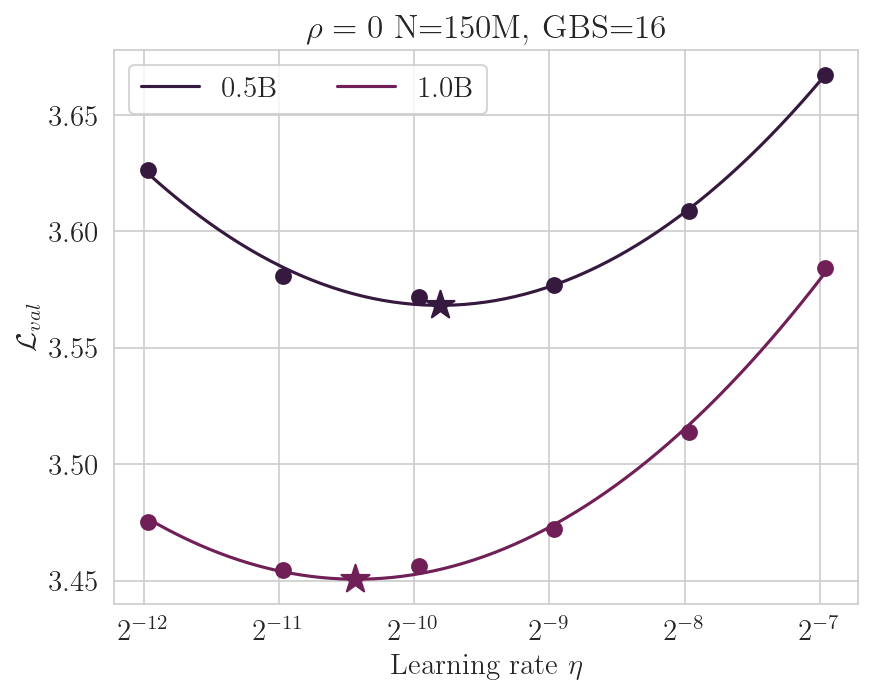

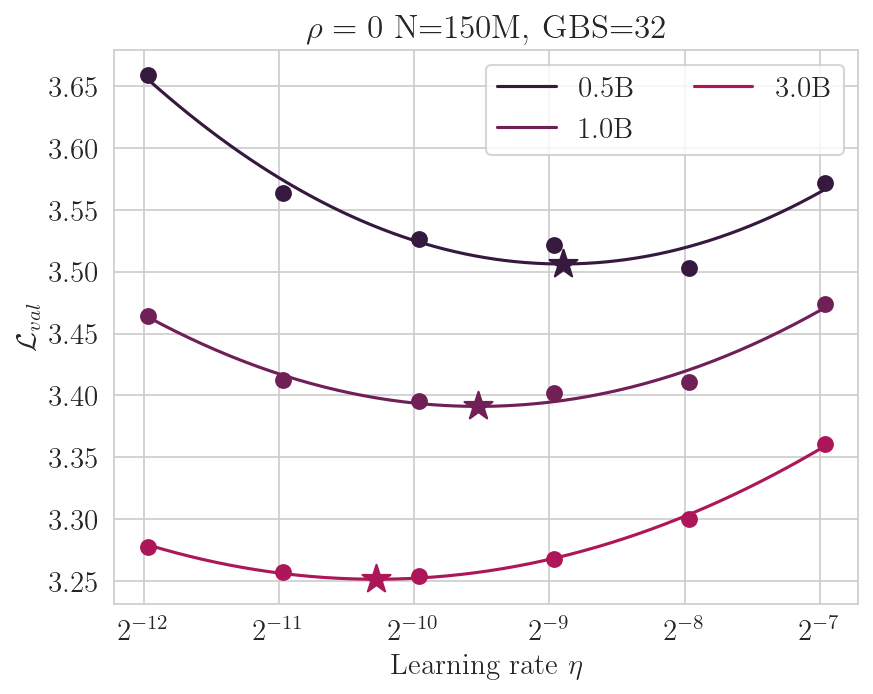

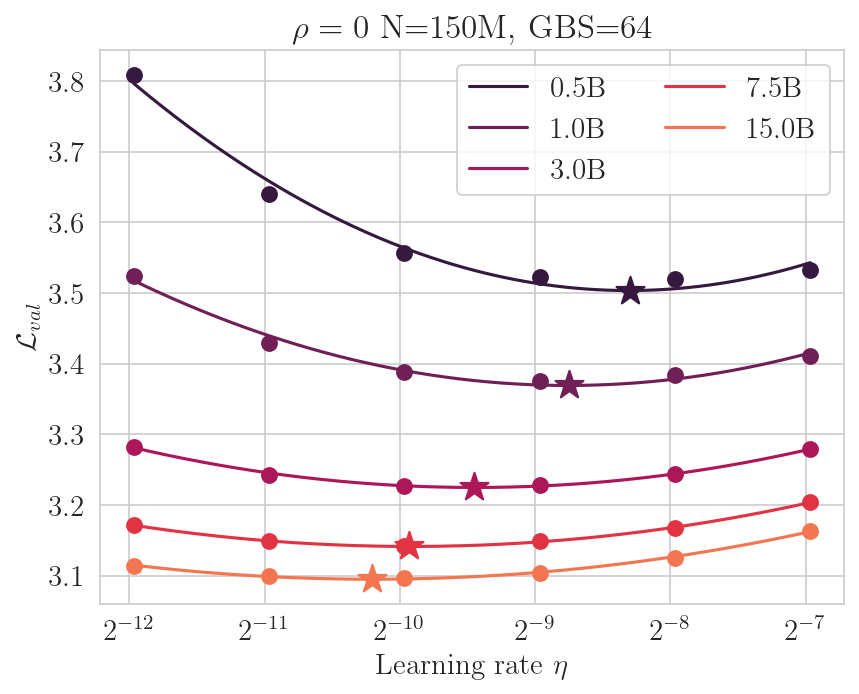

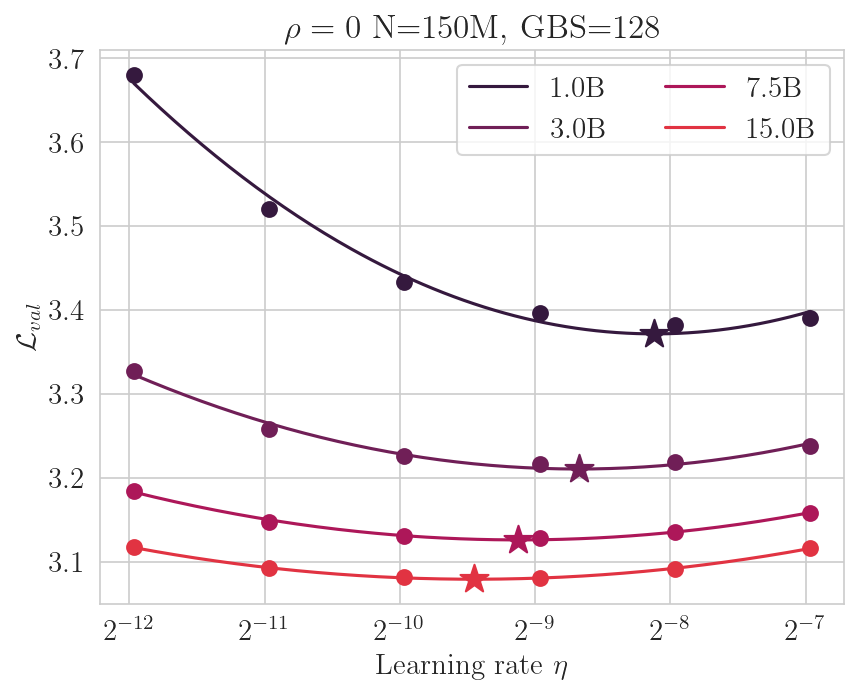

<Figure size 960x720 with 0 Axes>

In [192]:
def in_lr_grid(df):
    """Drop rows from superseded attn sweeps that used a different lr grid."""
    return df[df["lr"].isin(LRS)]


co = Collector("attn")
ns=["150M"]
gbss=[16, 32, 64, 128]

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = in_lr_grid(co.index(n=n, d=d, gbs=gbs))
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")
            if n == '300M' and d == '15.0B':
                print(n, gbs, d, xf_min)

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=0$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()


coefficients: [-0.28567565 -0.35011773 -0.04373272  0.69237766 -9.11025665]
matrix rank: 5
condition number: 2.475062026110859
log2-space R²: 0.9644989805420685


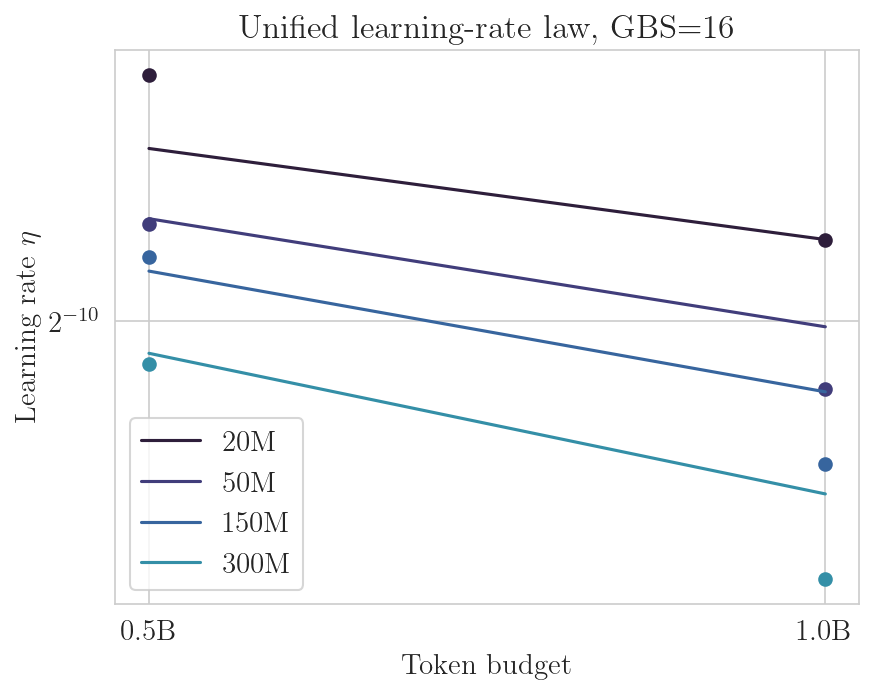

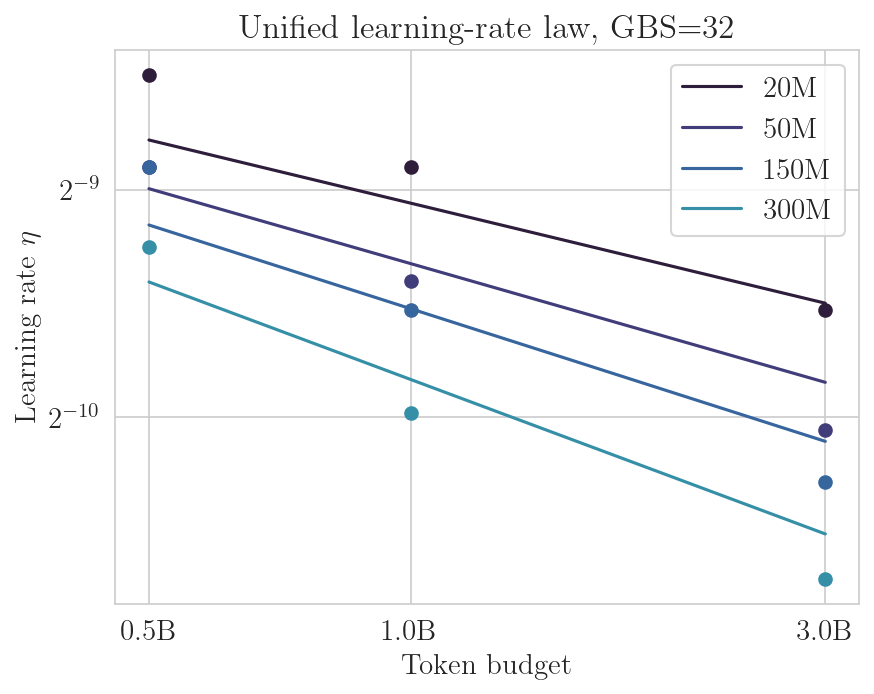

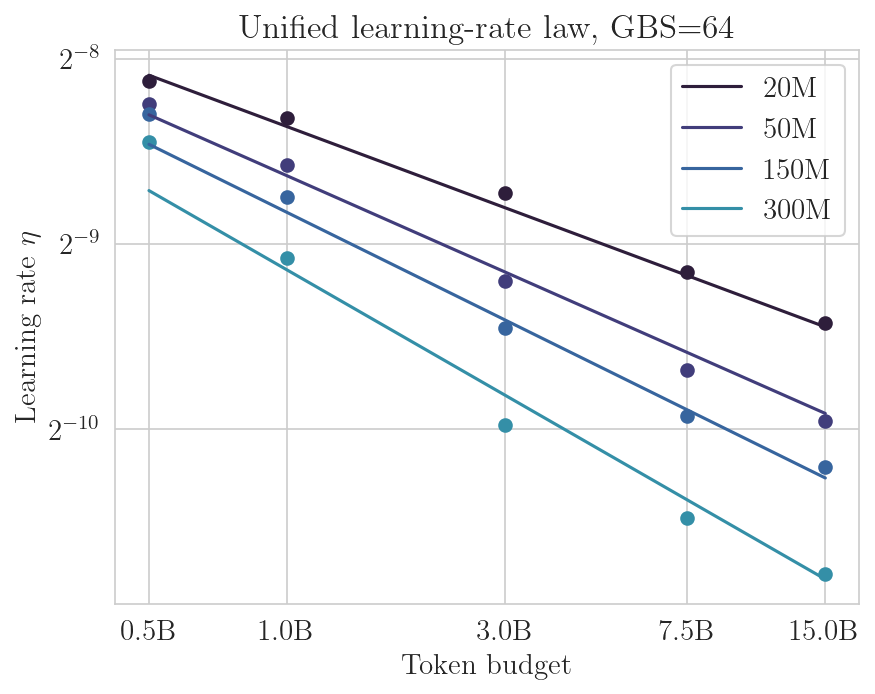

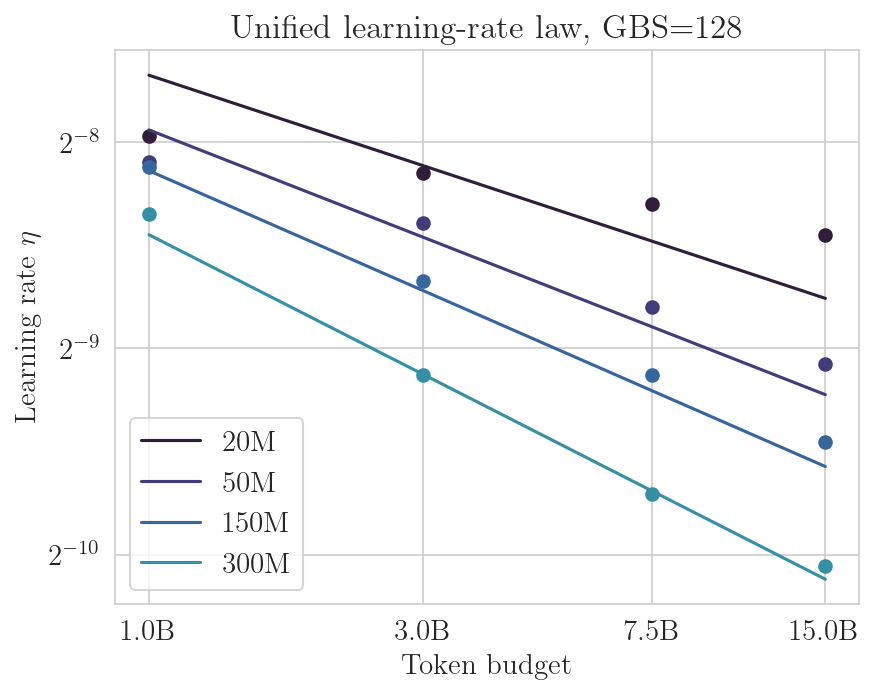

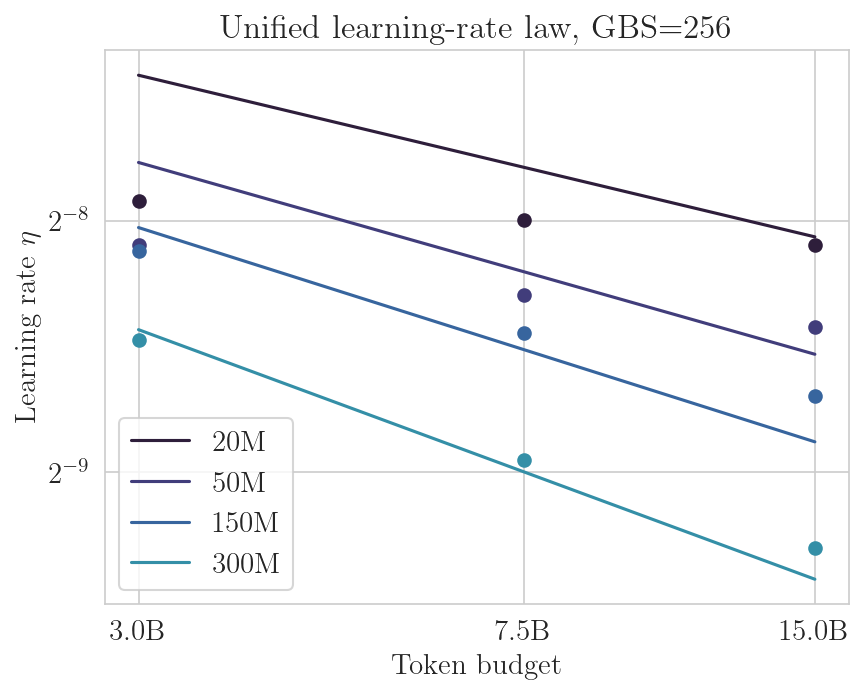

In [193]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "attn",
    gbss=[16, 32, 64, 128, 256],
    lr_filter=in_lr_grid,
)


In [194]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     229.1
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           8.83e-37
Time:                        13:48:05   Log-Likelihood:                 32.437
No. Observations:                  68   AIC:                            -54.87
Df Residuals:                      63   BIC:                            -43.78
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.1103      0.020   -4

## Pure GDN $\rho=1$

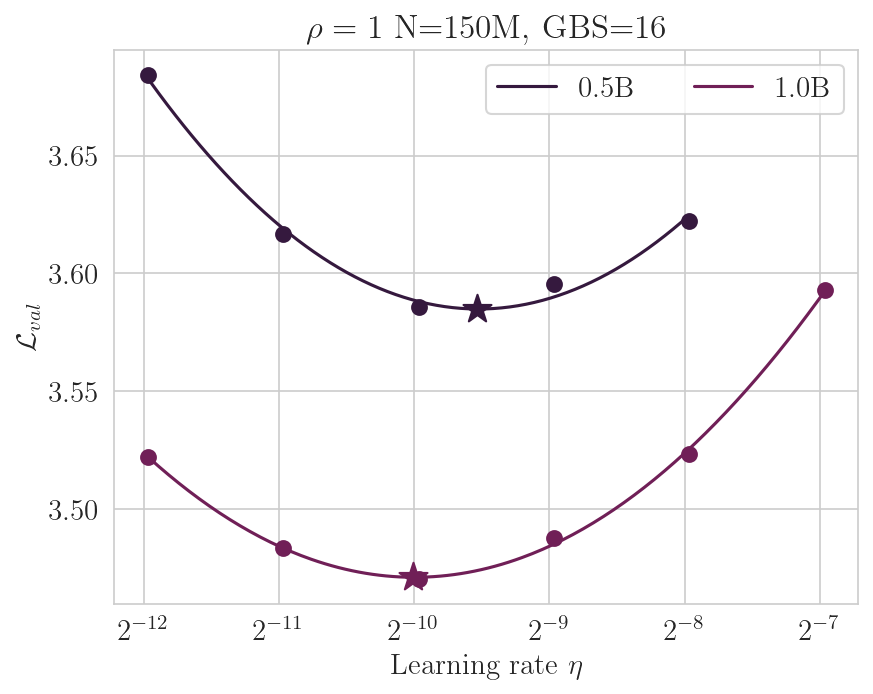

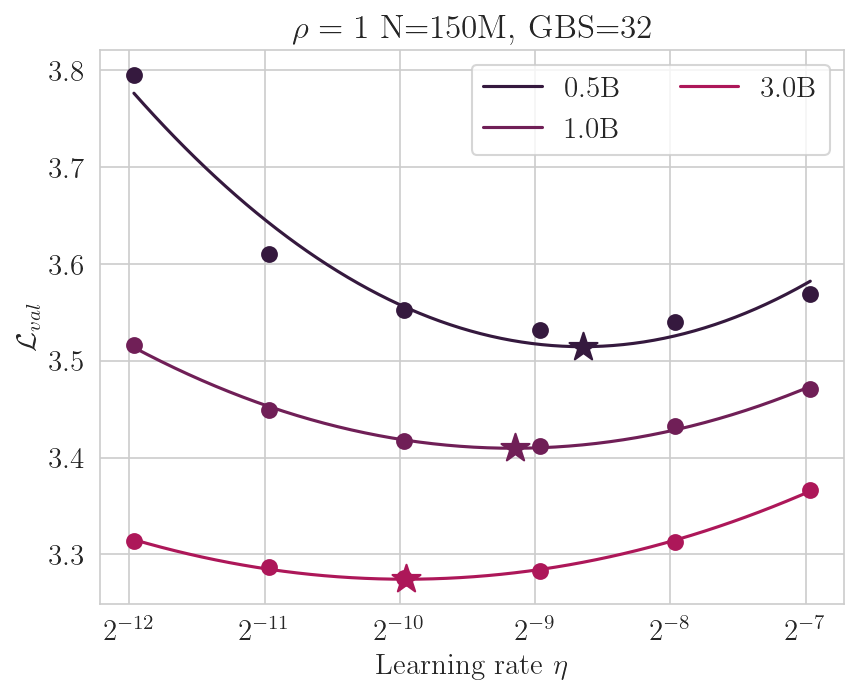

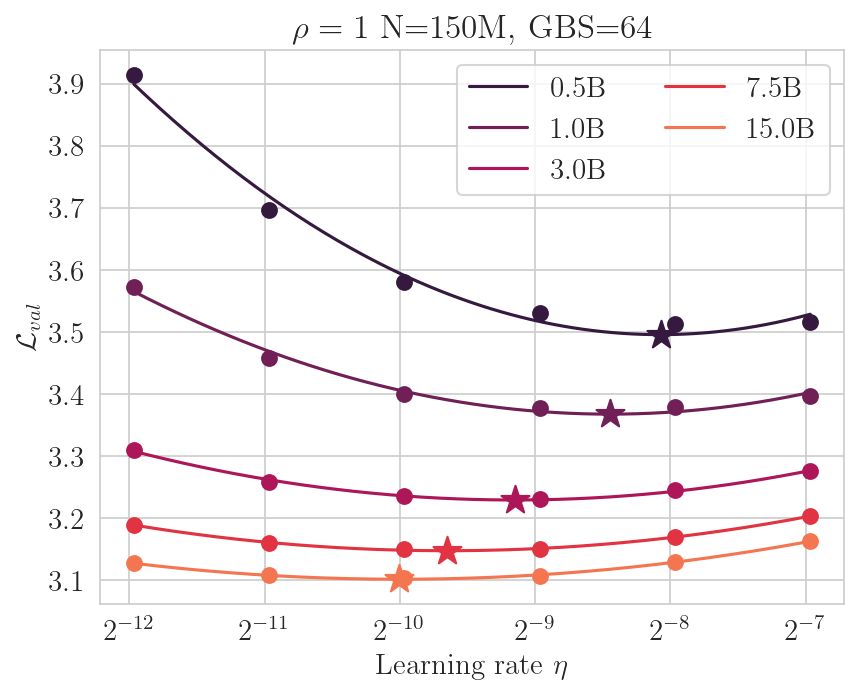

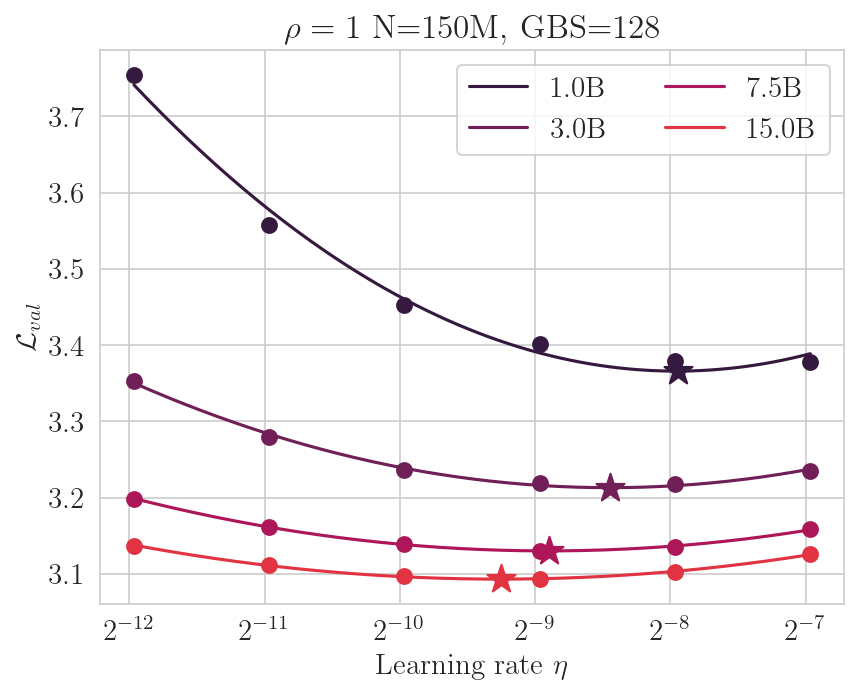

<Figure size 960x720 with 0 Axes>

In [195]:
ns=["150M"]
gbss=[16, 32, 64, 128]
co = Collector("gdn")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")
            if n == '300M' and d == '15.0B':
                print(n, gbs, d, xf_min)

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()


coefficients: [-0.27773274 -0.32268565 -0.04983794  0.60609211 -8.90502486]
matrix rank: 5
condition number: 2.637670397793383
log2-space R²: 0.9364726054114911


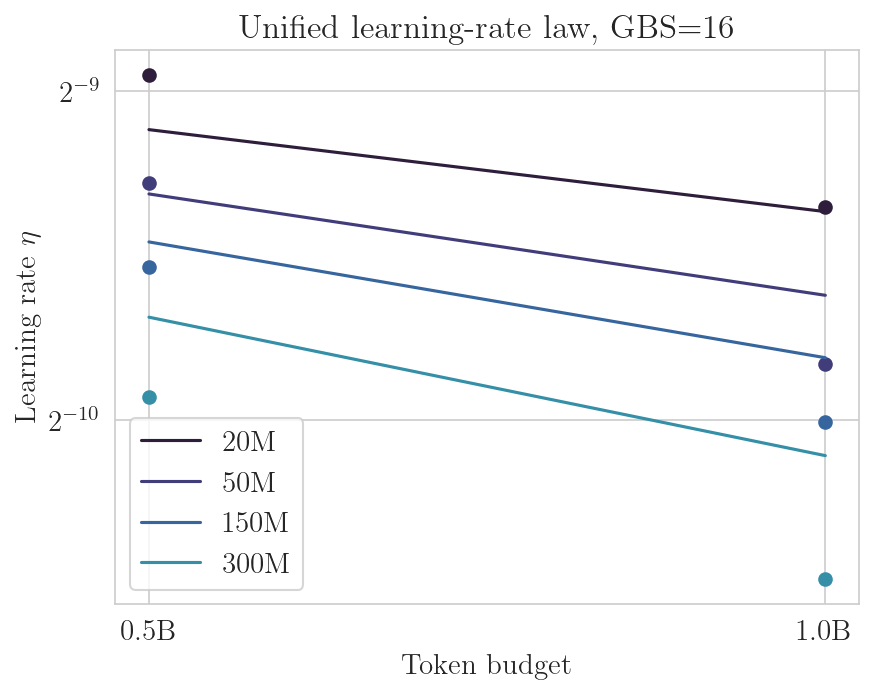

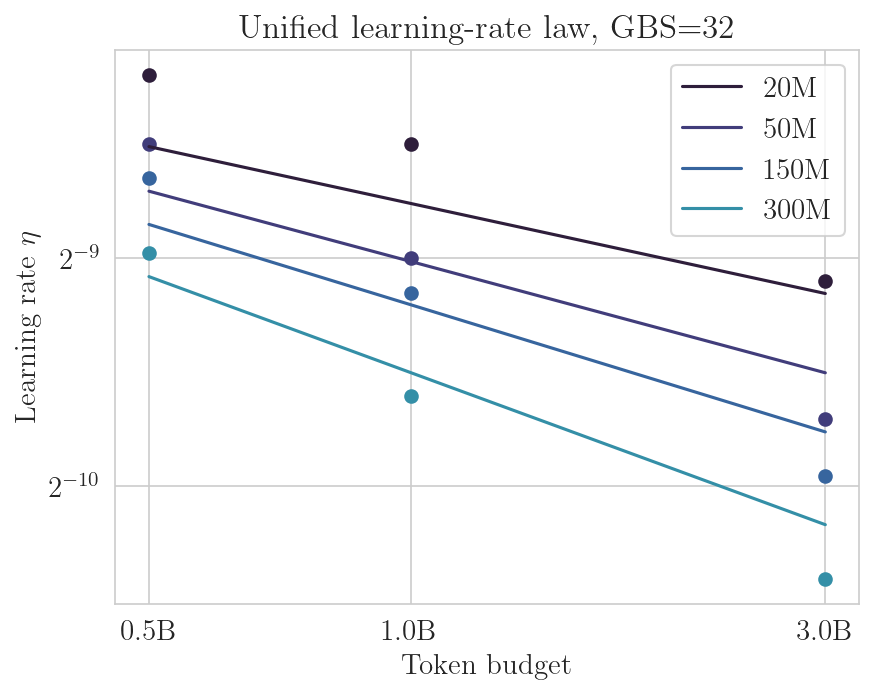

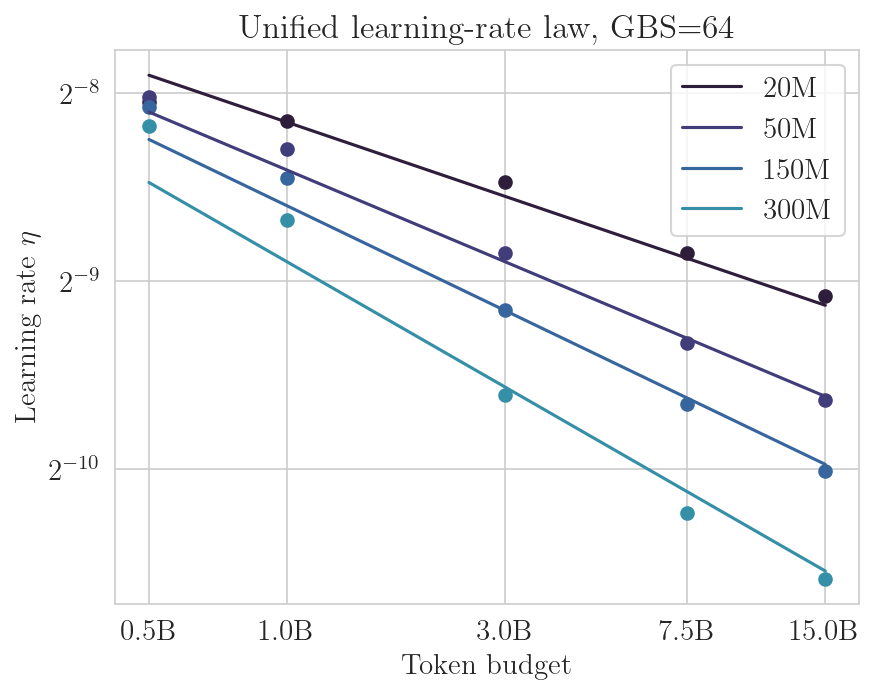

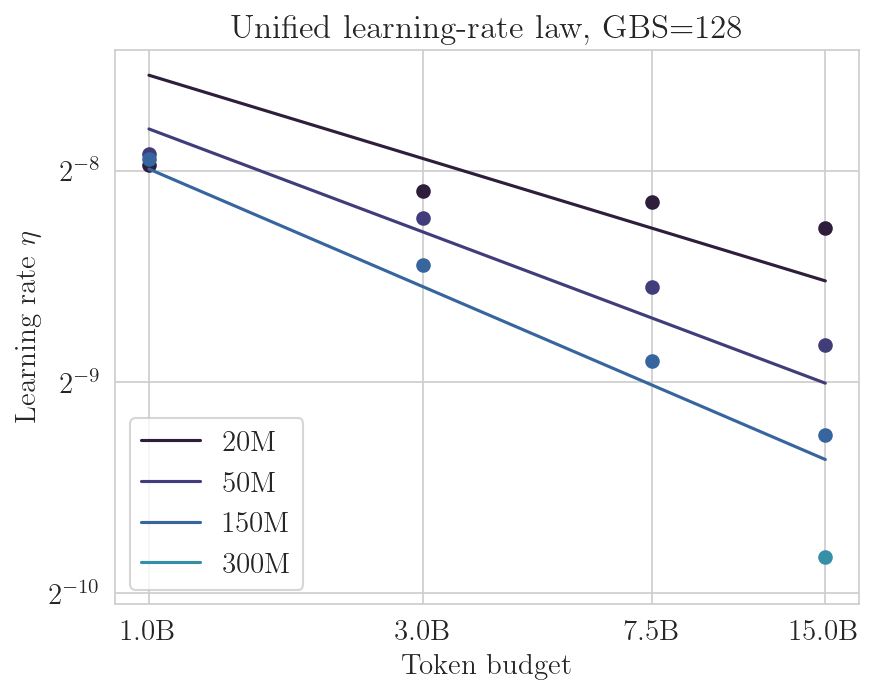

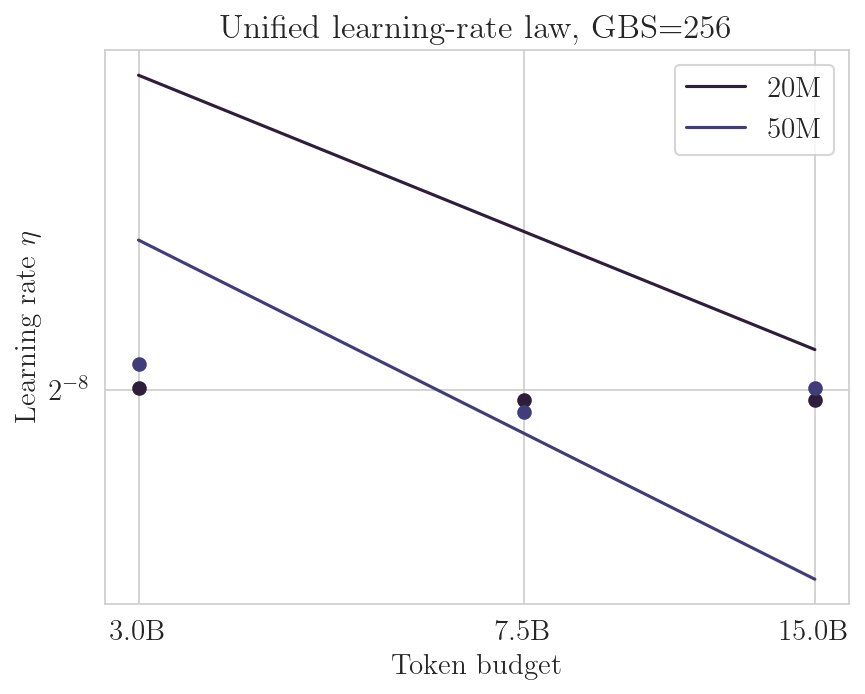

In [196]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn",
    gbss=[16, 32, 64, 128, 256],
)


In [197]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     119.8
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.57e-26
Time:                        13:48:05   Log-Likelihood:                 13.270
No. Observations:                  59   AIC:                            -16.54
Df Residuals:                      54   BIC:                            -6.152
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.9050      0.028   -3

## 1:1 GDN:ATTN $\rho=0.5$

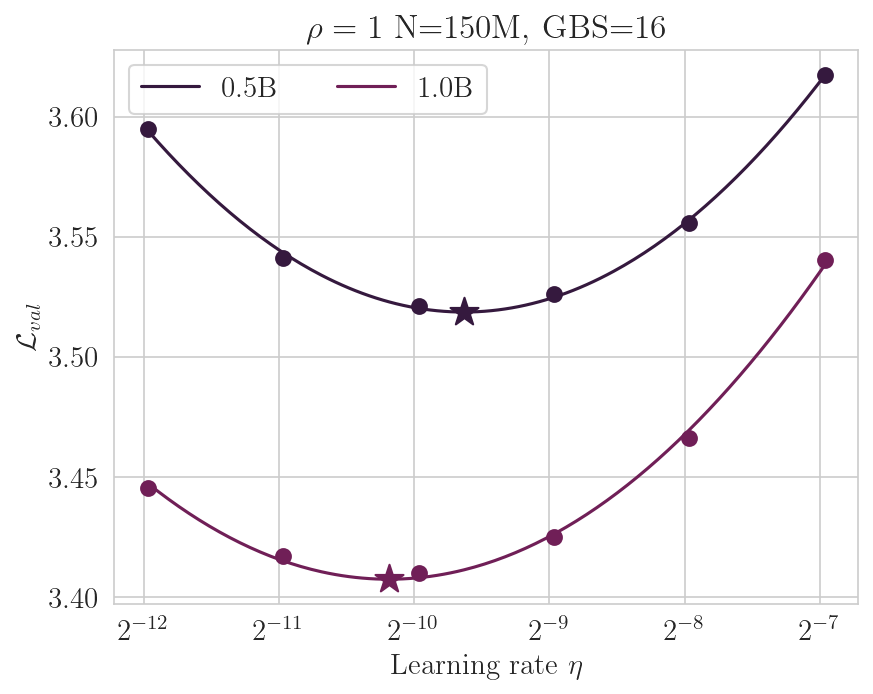

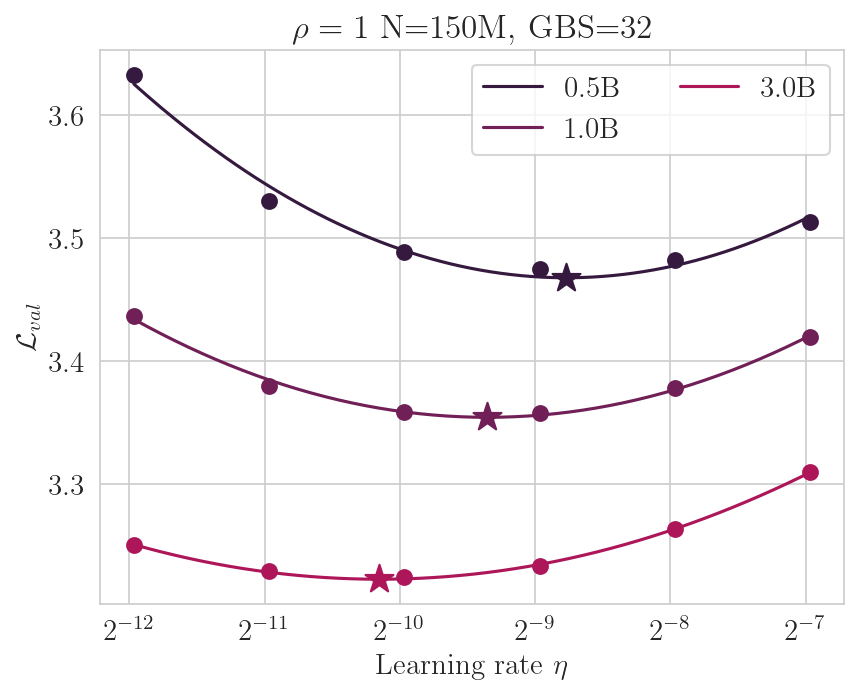

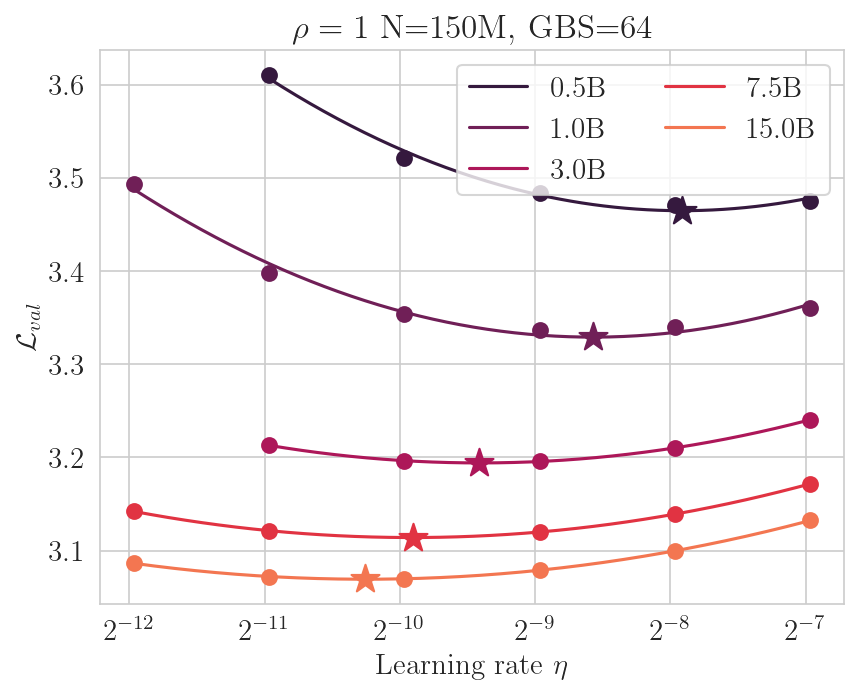

<Figure size 960x720 with 0 Axes>

In [198]:
ns=["150M"]
gbss=[16, 32, 64]
co = Collector("gdn+attn_1-1")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()

coefficients: [-0.25532003 -0.40205327 -0.04432008  0.69406483 -9.15313508]
matrix rank: 5
condition number: 2.7459485078013635
log2-space R²: 0.966962874225181


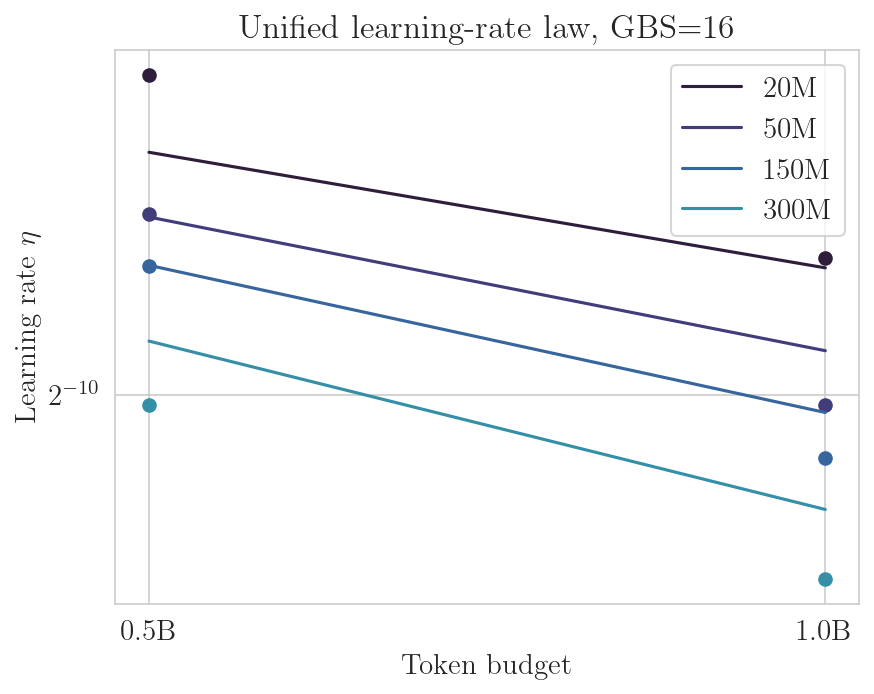

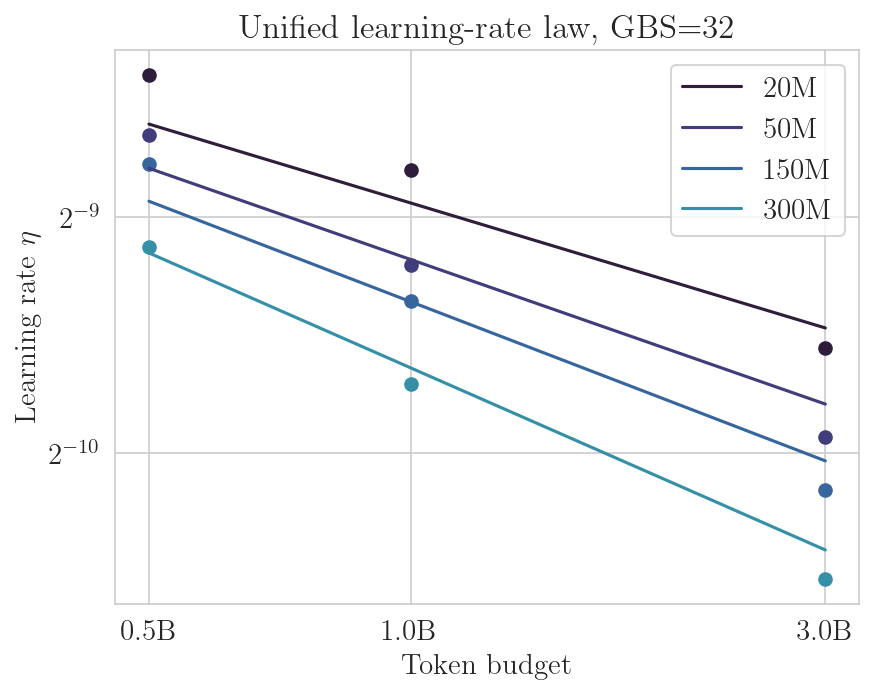

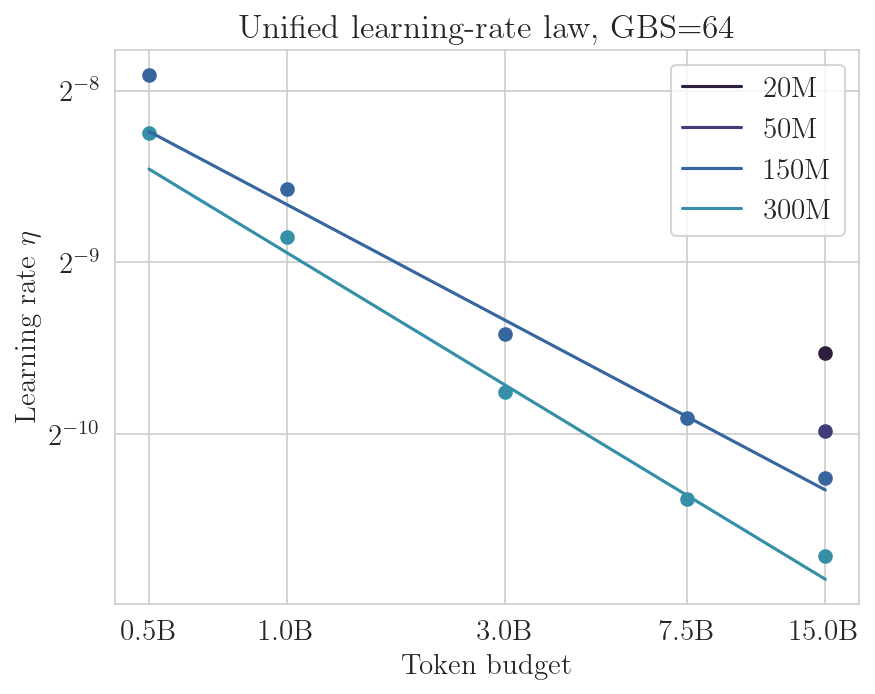

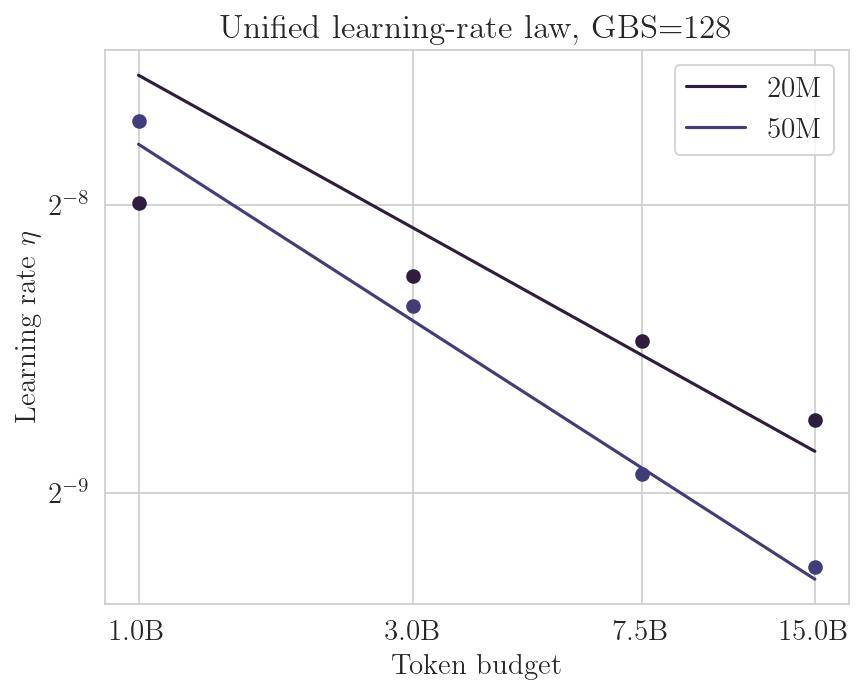

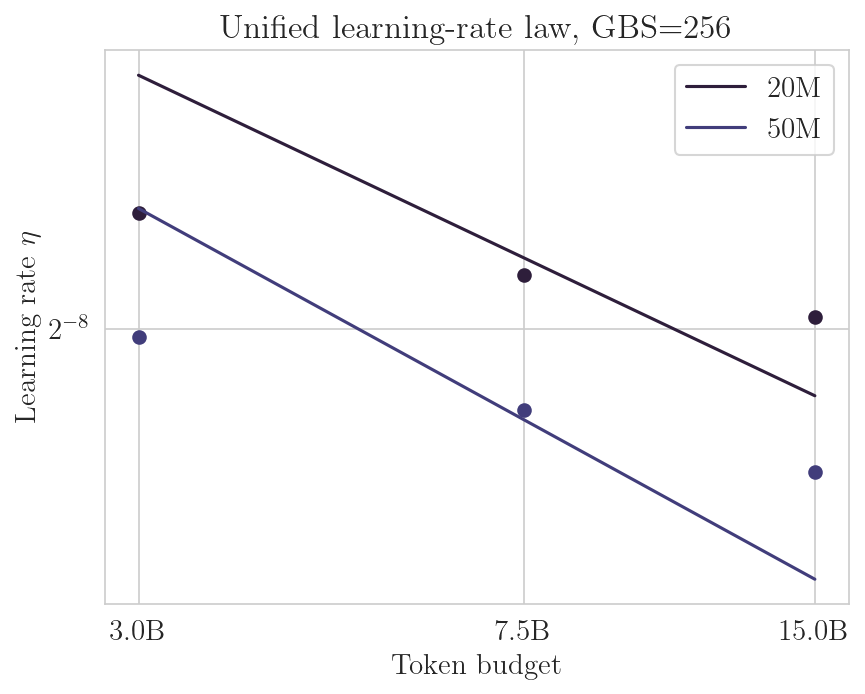

In [199]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn+attn_1-1",
    gbss=[16, 32, 64, 128, 256],
)


In [200]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     162.4
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.46e-24
Time:                        13:48:06   Log-Likelihood:                 20.514
No. Observations:                  46   AIC:                            -31.03
Df Residuals:                      41   BIC:                            -21.89
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.1531      0.029   -3

# 3:1 GDN:ATTN ($\rho=0.75$)

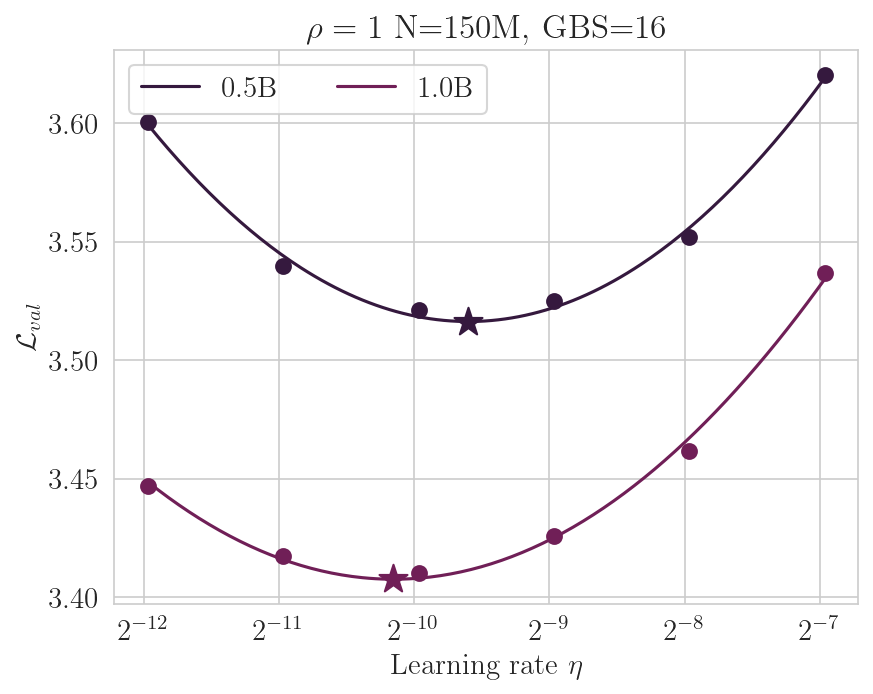

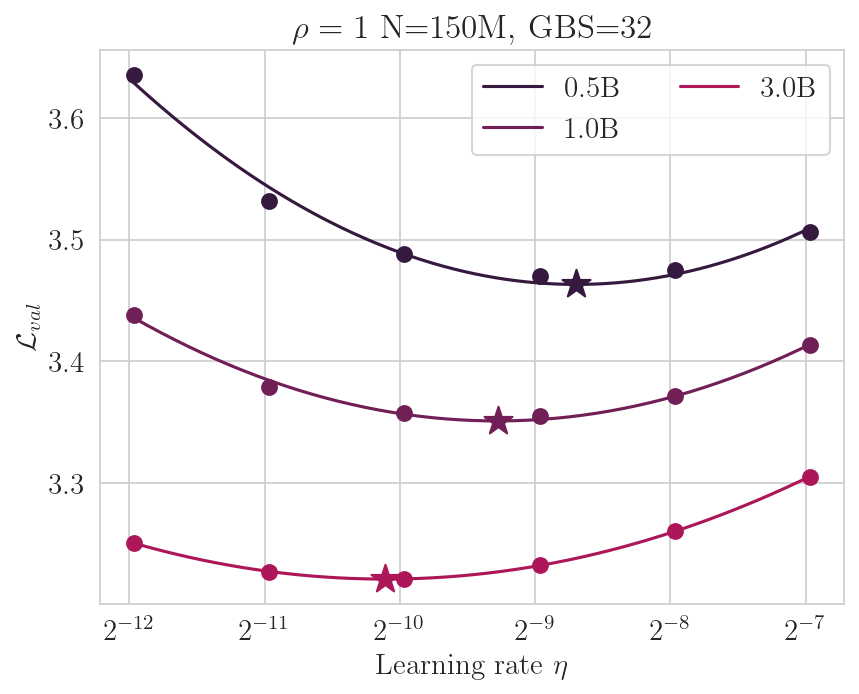

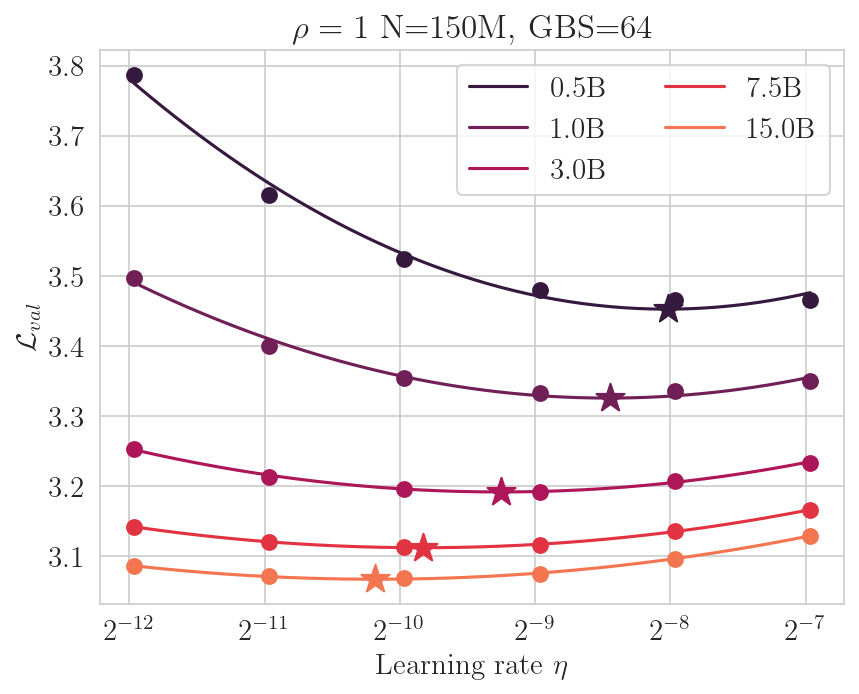

/var/folders/76/k9dkfmf92q19jtdmr7qd_nh00000gn/T/ipykernel_62514/1640562776.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncols=2)


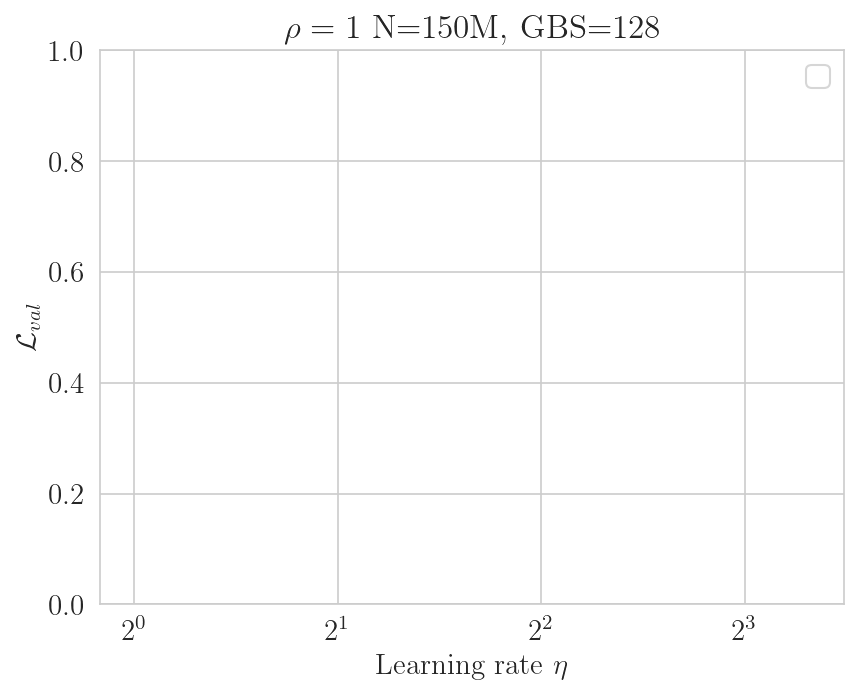

<Figure size 960x720 with 0 Axes>

In [201]:
ns=["150M"]
gbss=[16, 32, 64, 128]
co = Collector("gdn+attn_3-1")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()

coefficients: [-0.26808365 -0.37225755 -0.04259433  0.65532536 -9.05678478]
matrix rank: 5
condition number: 2.523776460635662
log2-space R²: 0.9493891628692169


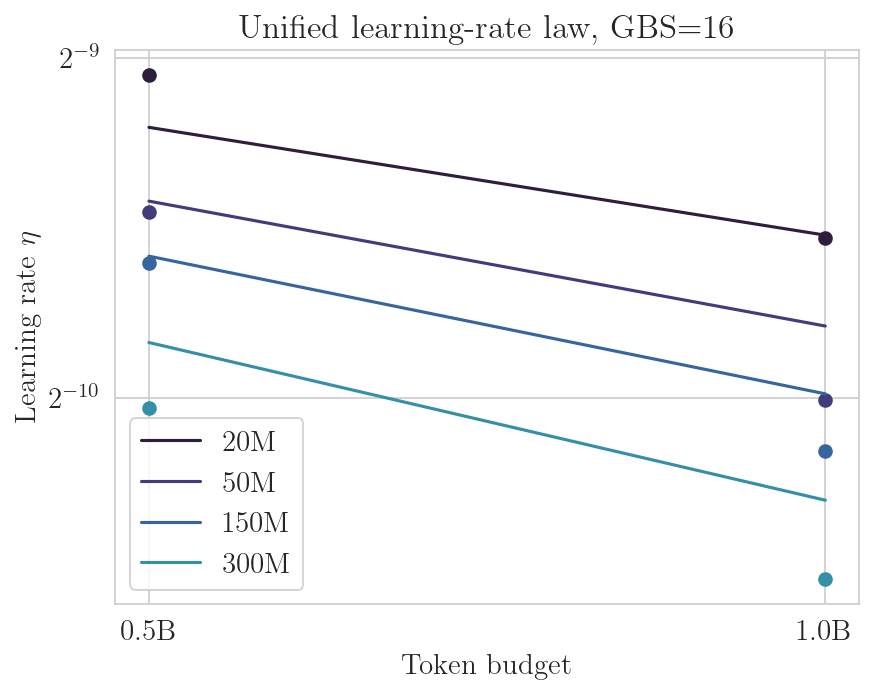

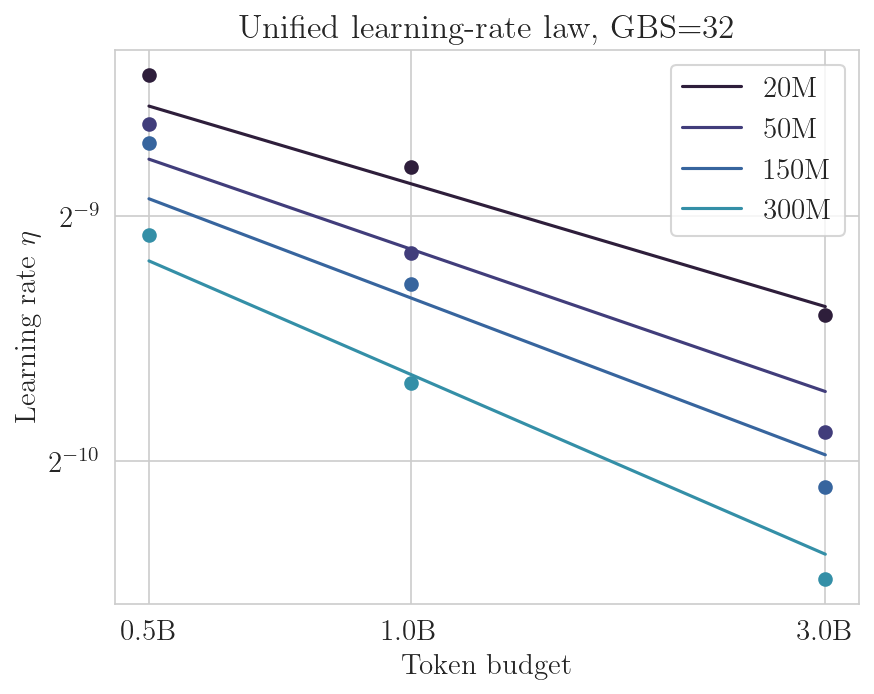

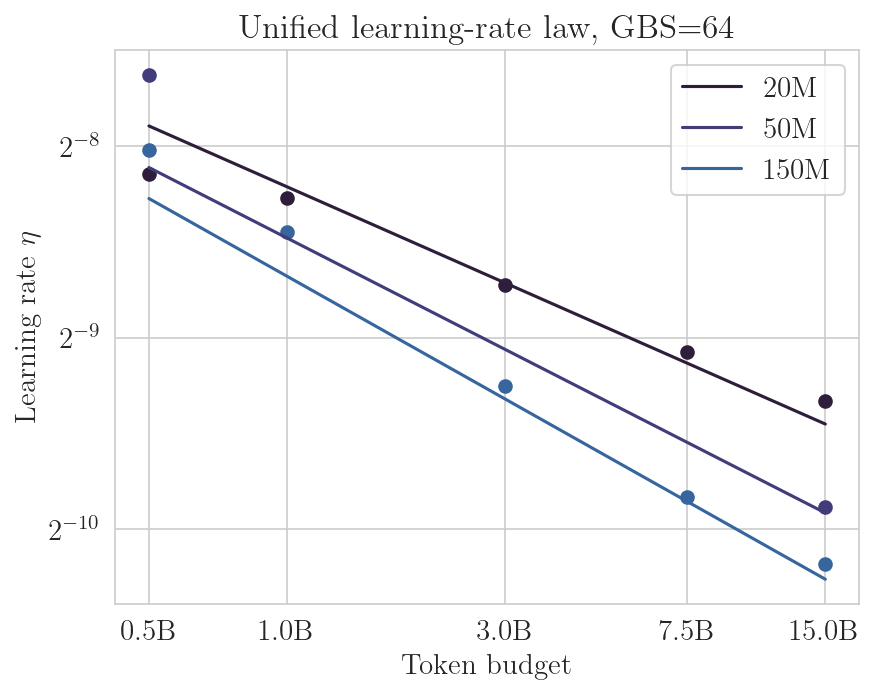

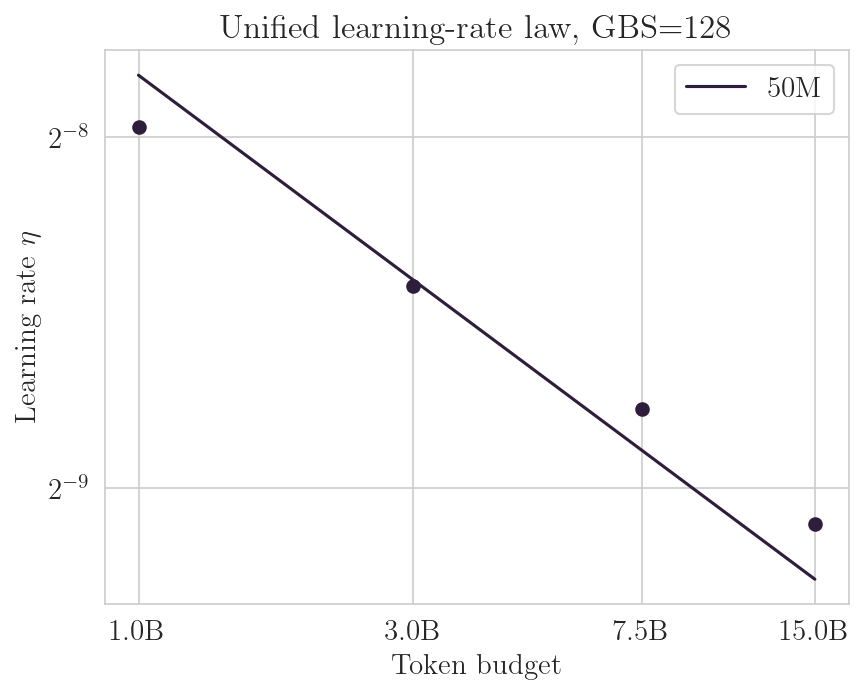

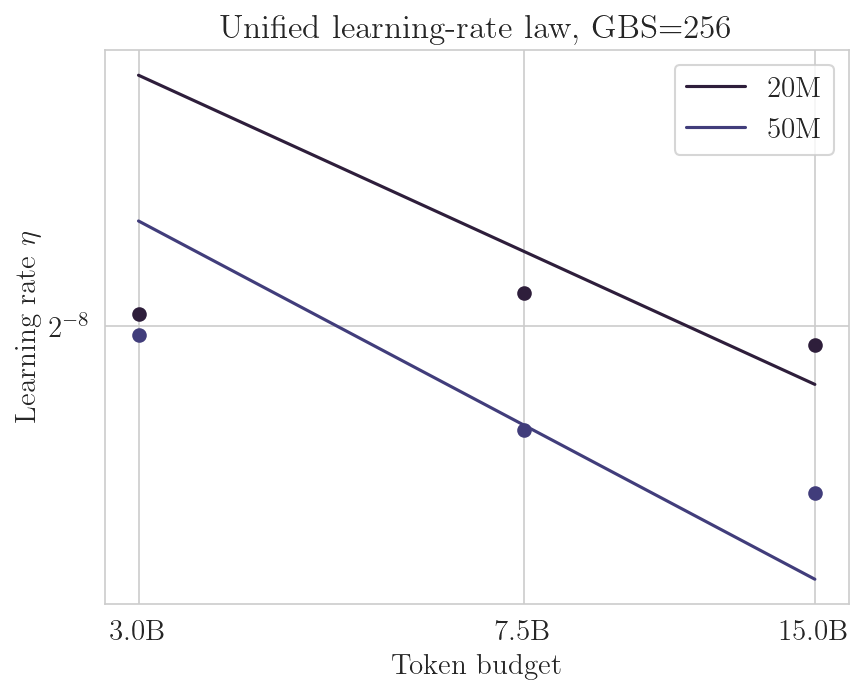

In [202]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn+attn_3-1",
    gbss=[16, 32, 64, 128, 256],
)


In [203]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     78.27
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.55e-17
Time:                        13:48:06   Log-Likelihood:                 13.070
No. Observations:                  42   AIC:                            -16.14
Df Residuals:                      37   BIC:                            -7.451
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.0568      0.031   -2

---
---

# Learning-rate transferability from Pure Attention

**What this section measures.** For every architecture $X \neq$ Pure Attention and every
cell $(N, D, \mathrm{GBS})$, take the loss-versus-lr quadratic already fitted for $X$ and
evaluate it at *Pure Attention's* optimal learning rate for the same cell. The gap

$$\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X)$$

is the loss cost of skipping the lr sweep for $X$ and reusing the Pure Attention value.
No new runs are needed: both numbers come from the same fitted curve.

**Reference scale.** $\Delta$ in nats is not interpretable alone, so each cell also carries
`grid_step_cost`: the loss cost, on that same curve, of being one lr grid step ($2\times$)
away from $X$'s own optimum. If $\Delta$ sits well below this, reusing the Pure Attention
learning rate is cheaper than the resolution of the sweep itself.

**Where to look**

| | Figure | Reads |
|---|---|---|
| Plot 1 | Transfer penalty per architecture | Headline: how large $\Delta$ is against the $2\times$-lr-error band |
| Plot 2 | $\eta^*_X$ against $\eta^*_{\rho=0}$ | Mechanism: how closely the optima coincide, and whether the offset is systematic |
| Plot 3 | $\Delta$ against compute $6ND$ | Whether transferability holds as scale grows |
| Plot 4 | One cell, both curves | Illustration of what $\Delta$ is |

$\rho=0.25$ (1:3) is excluded: those runs are not finished.


## Transfer table

In [204]:
import numpy as np
import pandas as pd

TRANSFER_ARCH_IDS = ["gdn", "gdn+attn_1-1", "gdn+attn_3-1"]

ARCH_LABELS = {
    "attn": r"$\rho=0$ (attn)",
    "gdn": r"$\rho=1$ (gdn)",
    "gdn+attn_1-1": r"$\rho=0.5$ (1:1)",
    "gdn+attn_3-1": r"$\rho=0.75$ (3:1)",
}


def quad_coeffs_log2(lrs, losses):
    """Quadratic fit of loss against log2(lr). Returns coeffs or None."""
    lrs = np.asarray(lrs, dtype=float)
    losses = np.asarray(losses, dtype=float)

    mask = np.isfinite(lrs) & np.isfinite(losses)
    lrs, losses = lrs[mask], losses[mask]

    if len(lrs) < 3:
        return None

    return np.polyfit(np.log2(lrs), losses, 2)


def quad_eval(coeffs, lr):
    a, b, c = coeffs
    x = np.log2(lr)
    return a * x**2 + b * x + c


def quad_min_log2(coeffs):
    """Vertex of the quadratic in log2(lr) space. Returns None if not a minimum."""
    a, b, _ = coeffs
    if a <= 0:
        return None
    return -b / (2.0 * a)


def cell_fit(collector, n, d, gbs, lr_filter=None):
    """Fit one (N, D, GBS) cell. Returns coeffs, log2 lr grid range, or None."""
    sl = collector.index(n=n, d=d, gbs=gbs)
    if lr_filter is not None:
        sl = lr_filter(sl)

    grouped = sl.groupby("lr")["val_loss"].mean().reset_index().dropna()
    coeffs = quad_coeffs_log2(grouped["lr"], grouped["val_loss"])
    if coeffs is None:
        return None

    log2_lrs = np.log2(grouped["lr"].values)
    return coeffs, log2_lrs.min(), log2_lrs.max()


def build_transfer_table(
    collectors,
    gbss,
    param_scales,
    data_scales_for,
    n_map,
    arch_ids=None,
    attn_lr_filter=None,
):
    """One row per comparable (arch, N, D, GBS) cell.

    For each cell the attention optimum is read off the attention fit at the
    same (N, D, GBS) and pushed through the architecture's own fitted curve.
    """
    if arch_ids is None:
        arch_ids = TRANSFER_ARCH_IDS

    rows = []

    for gbs in gbss:
        for n in param_scales:
            for d in data_scales_for(gbs):
                attn_fit = cell_fit(
                    collectors["attn"], n, d, gbs, lr_filter=attn_lr_filter
                )
                if attn_fit is None:
                    continue

                attn_coeffs, _, _ = attn_fit
                attn_vertex = quad_min_log2(attn_coeffs)
                if attn_vertex is None:
                    continue

                for arch_id in arch_ids:
                    fit = cell_fit(collectors[arch_id], n, d, gbs)
                    if fit is None:
                        continue

                    coeffs, log2_lr_lo, log2_lr_hi = fit
                    vertex = quad_min_log2(coeffs)
                    if vertex is None:
                        continue

                    loss_own = quad_eval(coeffs, 2.0**vertex)
                    loss_at_attn = quad_eval(coeffs, 2.0**attn_vertex)

                    # Cost of a single lr grid step (2x) away from the optimum,
                    # used as the reference scale for the transfer penalty.
                    grid_step_cost = 0.5 * (
                        quad_eval(coeffs, 2.0 ** (vertex + 1.0))
                        + quad_eval(coeffs, 2.0 ** (vertex - 1.0))
                    ) - loss_own

                    rows.append({
                        "arch_id": arch_id,
                        "n": n,
                        "d": d,
                        "gbs": gbs,
                        "params": n_map[n],
                        "tokens": float(d[:-1]) * 1e9,
                        "compute": 6.0 * n_map[n] * float(d[:-1]) * 1e9,
                        "lr_star": 2.0**vertex,
                        "lr_star_attn": 2.0**attn_vertex,
                        "log2_ratio": attn_vertex - vertex,
                        "loss_star": loss_own,
                        "loss_at_attn_lr": loss_at_attn,
                        "delta": loss_at_attn - loss_own,
                        "grid_step_cost": grid_step_cost,
                        "extrapolated": bool(
                            attn_vertex < log2_lr_lo or attn_vertex > log2_lr_hi
                        ),
                    })

    return pd.DataFrame(rows)


def transfer_summary(table):
    """Per-architecture summary of the transfer penalty."""
    band = table["grid_step_cost"].median()

    out = []
    for arch_id, group in table.groupby("arch_id"):
        out.append({
            "arch_id": arch_id,
            "cells": len(group),
            "median_delta": group["delta"].median(),
            "p90_delta": group["delta"].quantile(0.9),
            "max_delta": group["delta"].max(),
            "median_abs_log2_ratio": group["log2_ratio"].abs().median(),
            "frac_below_grid_step": (
                group["delta"] < group["grid_step_cost"]
            ).mean(),
            "extrapolated": int(group["extrapolated"].sum()),
        })

    summary = pd.DataFrame(out)
    summary.attrs["median_grid_step_cost"] = band
    return summary

In [220]:
def plot_transfer_penalty(table, ax=None):
    """Plot 1: distribution of the transfer penalty per architecture."""

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    band = table["grid_step_cost"].median()

    ax.axhline(band, color="0.35", ls="--", lw=1.2, zorder=1)
    ax.text(
        len(order) - 0.45,
        band * 1.1,
        r"median cost of a $2\times$ lr error",
        ha="right",
        va="bottom",
        fontsize=11,
        color="0.3",
    )

    sns.stripplot(
        data=table, x="arch_id", y="delta", order=order,
        hue="arch_id", hue_order=order, palette="rocket",
        size=6, alpha=0.7, jitter=0.25, legend=False, ax=ax, zorder=2,
    )
    sns.boxplot(
        data=table, x="arch_id", y="delta", order=order,
        showfliers=False, showbox=False, showcaps=False,
        whiskerprops={"visible": False},
        medianprops={"color": "k", "lw": 2},
        ax=ax, zorder=3,
    )

    ax.set_yscale("log")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([ARCH_LABELS[a] for a in order])
    ax.set_xlabel("Architecture")
    ax.set_ylabel(r"$\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X)$")
    ax.set_title("Cost of borrowing the Pure Attention learning rate")
    return ax


def plot_optimum_agreement(table, ax=None):
    """Plot 2: architecture optimum against the attention optimum."""

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    colors = sns.color_palette("rocket", n_colors=len(order))

    x = np.log2(table["lr_star_attn"])
    y = np.log2(table["lr_star"])
    lo = min(x.min(), y.min()) - 0.3
    hi = max(x.max(), y.max()) + 0.3
    line = np.array([lo, hi])

    ax.fill_between(line, line - 1.0, line + 1.0, color="0.85", zorder=0)
    ax.plot(line, line, color="0.3", ls="--", lw=1, zorder=1)

    markers = {16: "o", 32: "s", 64: "^", 128: "D", 256: "v"}

    for arch_id, color in zip(order, colors):
        group = table[table["arch_id"] == arch_id]
        for gbs, sub in group.groupby("gbs"):
            ax.scatter(
                np.log2(sub["lr_star_attn"]),
                np.log2(sub["lr_star"]),
                color=color,
                marker=markers.get(gbs, "o"),
                s=45,
                alpha=0.8,
                edgecolor="none",
                zorder=2,
            )

    handles = [
        plt.Line2D([], [], ls="none", marker="o", color=c, label=ARCH_LABELS[a])
        for a, c in zip(order, colors)
    ]
    handles += [
        plt.Line2D([], [], ls="none", marker=m, color="0.4", label=f"GBS={g}")
        for g, m in markers.items() if g in set(table["gbs"])
    ]
    ax.legend(handles=handles, fontsize=10, ncols=2, loc="upper left")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\log_2 \eta^*$ of Pure Attention")
    ax.set_ylabel(r"$\log_2 \eta^*$ of architecture $X$")
    ax.set_title(r"Optimal learning rates agree within one grid step")
    return ax


def plot_transfer_vs_compute(table, ax=None):
    """Plot 3: does the transfer penalty grow with compute?"""

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    colors = sns.color_palette("rocket", n_colors=len(order))

    # Median within log-spaced compute bins; the raw cells are too scattered
    # across nearby compute values to join directly.
    log_compute = np.log10(table["compute"])
    edges = np.linspace(log_compute.min(), log_compute.max() + 1e-9, 7)
    centres = 10.0 ** (0.5 * (edges[:-1] + edges[1:]))

    for arch_id, color in zip(order, colors):
        group = table[table["arch_id"] == arch_id]
        ax.scatter(
            group["compute"], group["delta"],
            color=color, s=30, alpha=0.45, edgecolor="none",
        )

        bin_index = np.digitize(np.log10(group["compute"]), edges) - 1
        medians = [
            np.median(group["delta"].values[bin_index == i])
            if np.any(bin_index == i) else np.nan
            for i in range(len(centres))
        ]
        ax.plot(
            centres, medians,
            color=color, lw=2, marker="o", ms=6, label=ARCH_LABELS[arch_id],
        )

    band = table["grid_step_cost"].median()
    ax.axhline(band, color="0.35", ls="--", lw=1.2)
    ax.text(
        table["compute"].min(), band * 1.1,
        r"median cost of a $2\times$ lr error",
        fontsize=11, color="0.3", va="bottom",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Compute $C = 6ND$ (FLOPs)")
    ax.set_ylabel(r"Transfer penalty $\Delta$")
    ax.set_title("Transfer penalty against compute")
    ax.legend(fontsize=11, loc="lower left")
    return ax


def plot_transfer_example(
    collectors, n, d, gbs, arch_ids, attn_lr_filter=None, ax=None
):
    """Plot 4: one cell, showing where each transfer penalty comes from."""

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    if isinstance(arch_ids, str):
        arch_ids = [arch_ids]

    architecture_ids = ["attn", *arch_ids]
    colors = sns.color_palette("rocket", n_colors=len(architecture_ids))
    fit_rows = []

    for arch_id, color in zip(architecture_ids, colors):
        lr_filter = attn_lr_filter if arch_id == "attn" else None
        coeffs, log2_lo, log2_hi = cell_fit(
            collectors[arch_id], n, d, gbs, lr_filter=lr_filter
        )
        fit_rows.append({
            "arch_id": arch_id,
            "color": color,
            "coeffs": coeffs,
            "vertex": quad_min_log2(coeffs),
            "log2_lo": log2_lo,
            "log2_hi": log2_hi,
            "lr_filter": lr_filter,
        })

    grid = np.linspace(
        min(row["log2_lo"] for row in fit_rows),
        max(row["log2_hi"] for row in fit_rows),
        200,
    )

    for row in fit_rows:
        coeffs = row["coeffs"]
        vertex = row["vertex"]
        color = row["color"]
        ax.plot(
            2.0**grid,
            quad_eval(coeffs, 2.0**grid),
            color=color,
            label=ARCH_LABELS[row["arch_id"]],
        )
        ax.scatter(
            2.0**vertex,
            quad_eval(coeffs, 2.0**vertex),
            marker="*",
            s=250,
            color=color,
            zorder=3,
        )

        observations = collectors[row["arch_id"]].index(
            n=n, d=d, gbs=gbs
        )
        if row["lr_filter"] is not None:
            observations = row["lr_filter"](observations)
        grouped = observations.groupby("lr")["val_loss"].mean().reset_index()
        ax.scatter(
            grouped["lr"],
            grouped["val_loss"],
            color=color,
            s=40,
            alpha=0.6,
            edgecolor="none",
        )

    attn_vertex = fit_rows[0]["vertex"]
    attn_lr = 2.0**attn_vertex
    penalty_labels = []

    ax.axvline(attn_lr, color="0.5", ls=":", lw=1)
    for row in fit_rows[1:]:
        loss_own = quad_eval(row["coeffs"], 2.0**row["vertex"])
        loss_at_attn = quad_eval(row["coeffs"], attn_lr)
        ax.vlines(
            attn_lr,
            loss_own,
            loss_at_attn,
            color=row["color"],
            lw=2.2,
            zorder=4,
        )
        penalty_labels.append(
            rf"{ARCH_LABELS[row['arch_id']]}: $\Delta={loss_at_attn - loss_own:.4f}$"
        )

    ax.text(
        0.02,
        0.98,
        "\n".join(penalty_labels),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(r"Learning rate $\eta$")
    ax.set_ylabel(r"$\mathcal{L}_{val}$")
    ax.set_title(f"N={n}, D={d}, GBS={gbs}")
    ax.legend(fontsize=11)
    return ax

In [206]:
def in_transfer_lr_grid(df):
    """Drop rows from superseded attn sweeps that used a different lr grid."""
    return df[df["lr"].isin(LRS)]


transfer_collectors = {
    arch_id: Collector(arch_id)
    for arch_id in ["attn"] + TRANSFER_ARCH_IDS
}

transfer_table = build_transfer_table(
    transfer_collectors,
    gbss=[16, 32, 64, 128, 256],
    param_scales=PARAM_SCALES,
    data_scales_for=data_scales_for,
    n_map=N_MAP,
    attn_lr_filter=in_transfer_lr_grid,
)

summary = transfer_summary(transfer_table)
print(f"cells: {len(transfer_table)}")
print(f"median cost of a 2x lr error: {summary.attrs['median_grid_step_cost']:.5f}")
print()
print(summary.to_string(float_format=lambda value: f"{value:.5g}"))

cells: 147
median cost of a 2x lr error: 0.01134

        arch_id  cells  median_delta  p90_delta  max_delta  median_abs_log2_ratio  frac_below_grid_step  extrapolated
0           gdn     59    0.00083731  0.0019018  0.0031118                0.28559                     1             0
1  gdn+attn_1-1     46      0.000178 0.00080048  0.0024636                0.13811                     1             0
2  gdn+attn_3-1     42    0.00020843 0.00096199  0.0061711                0.12762                     1             0


## Plot 1: transfer penalty per architecture

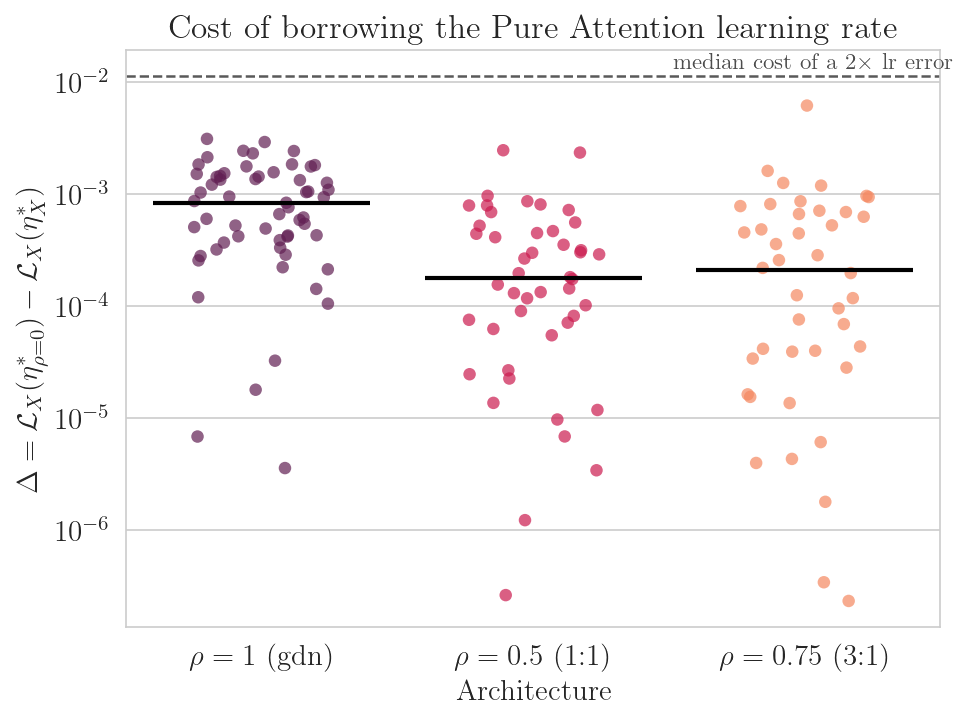

In [207]:
sns.set_palette(sns.color_palette("rocket"))

plot_transfer_penalty(transfer_table)
plt.show()
plt.close()

### Interpretation

**Question.** How much validation loss do we add if we use the learning rate selected for
Pure Attention instead of selecting a separate learning rate for each architecture?

**Construction.** Each point represents one matched $(N,D,\mathrm{GBS})$ setting. For an
architecture $X$, we fit validation loss as a quadratic function of $\log_2 \eta$. We then
compare the minimum of this fitted curve with its value at the fitted Pure Attention
optimum for the same setting:

$$\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X).$$

The y-axis shows this fitted loss penalty on a log scale. The black bar is the median for
each architecture. The dashed line is a reference value: the median fitted cost, across all
cells, of moving a factor of two above or below an architecture's own optimum. A factor of
two is one step on the learning-rate grid used in these sweeps.

**Result.** The transfer penalty is small for all 147 matched cells. The largest fitted
penalty is 0.0062 nats, below the 0.0113-nat reference line. Median penalties are
0.00084 for Pure GDN, 0.00018 for the 1:1 hybrid, and 0.00021 for the 3:1 hybrid. Pure GDN
has the largest typical penalty, but the plot does not by itself explain why.

**Limitations.** These are estimates from quadratic fits, not losses measured in new runs
at the transferred learning rates. The dashed line is a single median reference; it is not
the factor-of-two cost for every individual cell. The table above provides the stronger
cell-wise check: every transfer penalty is below its own cell's factor-of-two cost. This
supports using the Pure Attention learning rate within the tested grid, but does not show
that the transferred rate is exactly optimal.


## Plot 2: agreement of the optima

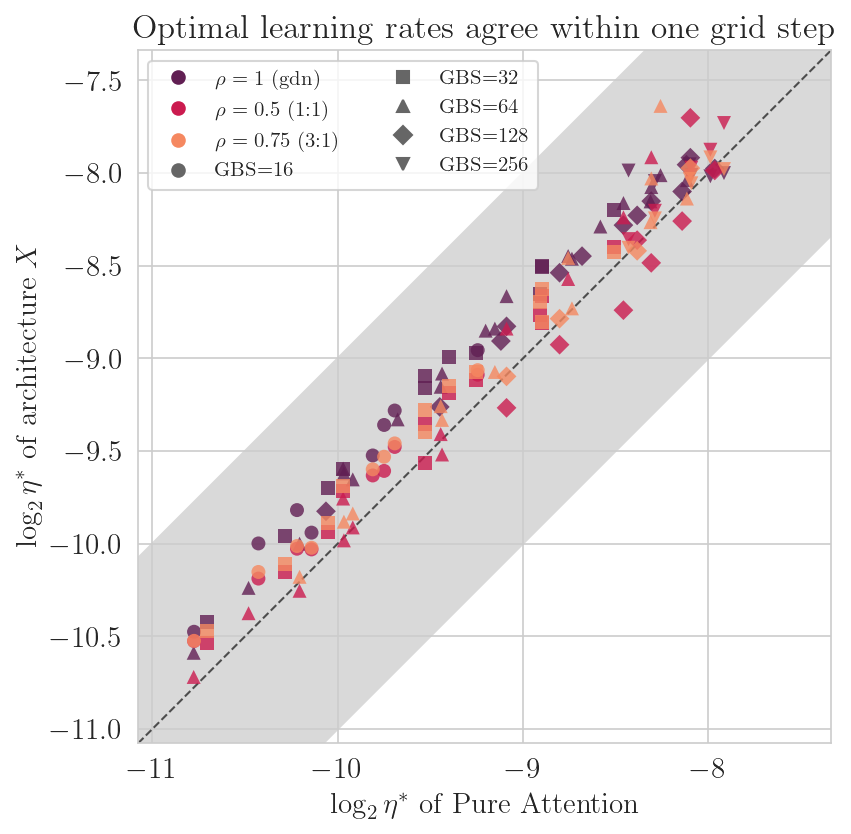

In [208]:
plot_optimum_agreement(transfer_table)
plt.show()
plt.close()

### Interpretation

**Question.** Are the fitted optimal learning rates themselves similar, or is the loss
penalty small only because the loss curves are flat near their minima?

**Construction.** Each point compares two fitted optima for the same
$(N,D,\mathrm{GBS})$ setting. The x-coordinate is the Pure Attention optimum and the
y-coordinate is the optimum for architecture $X$. Both axes use $\log_2 \eta$, matching
the factor-of-two spacing of the sweep. Colour identifies the architecture and marker
shape identifies global batch size. The dashed diagonal means exact agreement. The grey
band contains pairs whose optima differ by less than a factor of two.

**Result.** All 147 fitted pairs lie inside the factor-of-two band, and the largest
difference is 0.62 on the $\log_2$ scale. The median absolute difference is 0.29 for Pure
GDN and about 0.13 for each hybrid. The points are generally close to the diagonal, so the
small penalties in Plot 1 are not explained only by flat loss curves: the fitted optima
are also close. The points tend to lie slightly above the diagonal, indicating that the
other architectures often prefer a somewhat larger learning rate than Pure Attention.

**Limitations.** The points are vertices of fitted quadratics, not directly observed
optima, and the plot does not show uncertainty in those vertices. Being inside the grey
band means only that the fitted rates differ by less than a factor of two; it does not mean
that a discrete sweep would select the same grid point. Marker shapes provide a visual
check for a strong batch-size pattern, but this figure alone cannot establish that one
constant correction works across $N$, $D$, and GBS.


## Plot 3: transfer penalty against compute

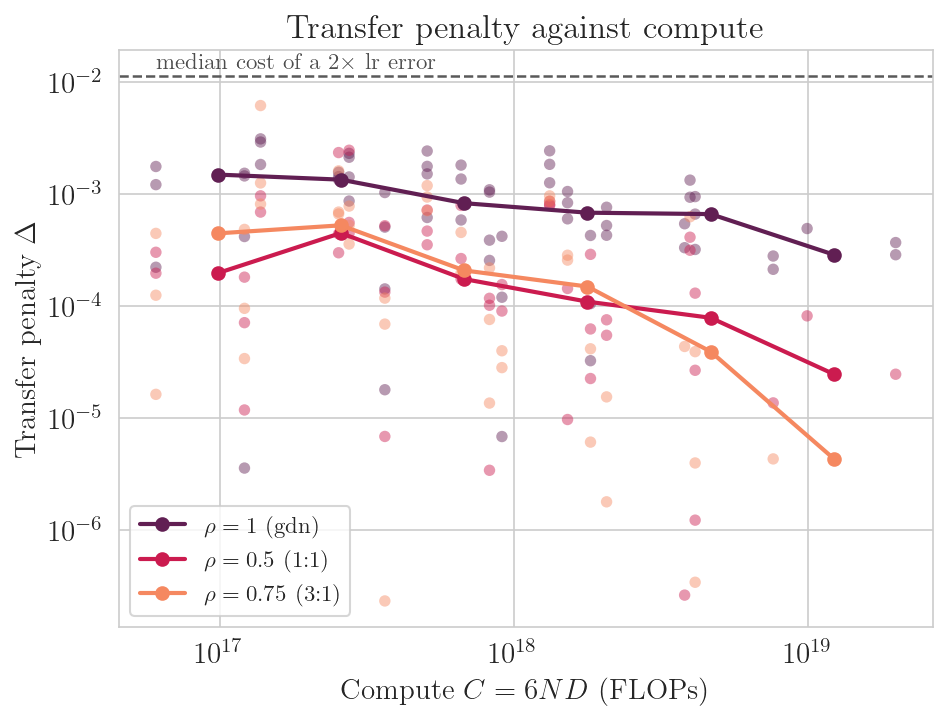

In [209]:
plot_transfer_vs_compute(transfer_table)
plt.show()
plt.close()

### Interpretation

**Question.** Does the cost of transferring the Pure Attention learning rate increase over
the range of training compute covered by these experiments?

**Construction.** The x-axis is estimated training compute, $C=6ND$, on a log scale. The
y-axis is the fitted transfer penalty $\Delta$ from Plot 1, also on a log scale. Faint
points are individual $(N,D,\mathrm{GBS})$ cells. For each architecture, the solid line
shows the median penalty in each of six equal-width bins of $\log_{10} C$. Binning gives a
readable summary because several combinations of $N$, $D$, and GBS have similar compute.
The dashed line is the same overall median factor-of-two reference used in Plot 1.

**Result.** Within the observed compute range, the binned median penalties are broadly flat
or decreasing and remain below the reference line. Pure GDN usually has a larger penalty
than the two hybrid models. There is therefore no visible evidence in these experiments
that transfer becomes worse as compute increases.

**Limitations.** This plot describes the tested range; it does not test transfer at larger
compute and cannot justify unrestricted extrapolation. Compute combines model size and
token budget into one number, so it can hide separate effects of $N$ and $D$. The binned
lines are descriptive medians with no uncertainty intervals, and the cells within and
across bins are not necessarily independent. A flat trend should therefore be read as
'no degradation detected over this range', not as proof that the penalty is scale
invariant.


## Plot 4: one cell, for intuition

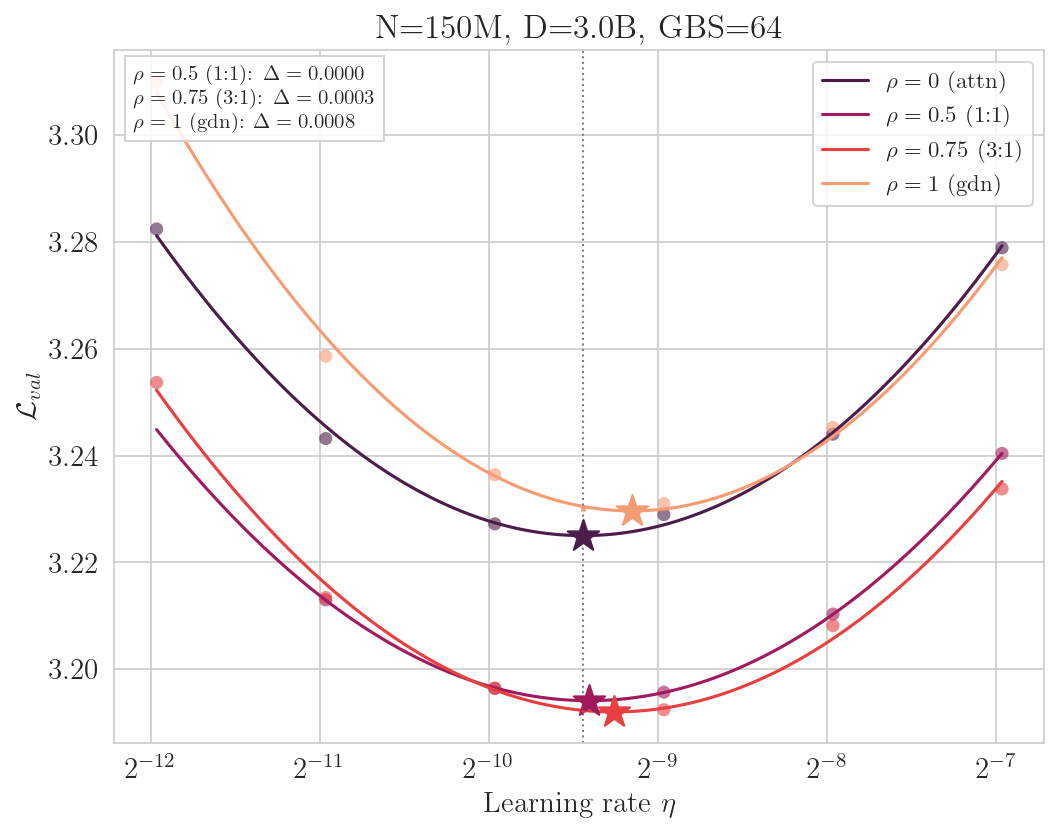

In [221]:
plot_transfer_example(
    transfer_collectors,
    n="150M",
    d="3.0B",
    gbs=64,
    arch_ids=["gdn+attn_1-1", "gdn+attn_3-1", "gdn"],
    attn_lr_filter=in_transfer_lr_grid,
)
plt.show()
plt.close()

### Interpretation

**Question.** How is the transfer penalty calculated for one concrete training setting?

**Construction.** This example uses $N=150$M, $D=3.0$B, and $\mathrm{GBS}=64$. The points
show the mean validation loss at each sampled learning rate for Pure Attention, the 1:1
hybrid ($\rho=0.5$), the 3:1 hybrid ($\rho=0.75$), and Pure GDN. The curves are quadratic
fits in $\log_2 \eta$, and each star marks the minimum of one fitted curve. The dotted
line marks the fitted Pure Attention optimum. The coloured vertical segments show the
increase in fitted loss when that rate is used instead of each architecture's own fitted
optimum. The box reports the corresponding $\Delta$ values.

**Why this plot is useful.** It shows the measured points, fitted curves, and fitted optima
for all four architectures together. This makes the calculation behind Plots 1--3 visible and lets
the reader inspect whether the quadratic is a reasonable local description of the sweep.
It also shows why different optimal rates can have small loss penalties when the curves
are shallow near their minima.

**Limitations.** This is an illustration from one cell, not evidence that transfer works
for every configuration. The stars and the arrow are derived from fitted curves; they are
not additional training runs at those exact learning rates. The figure also gives no
uncertainty for the curve or its minimum. The aggregate result comes from Plot 1 and the
transfer table, which repeat this calculation across all 147 matched cells.


---
---

# Out-of-sample validation of the learning-rate law

These tests use the same two-stage method as the main analysis. First, a quadratic in
$\log_2 \eta$ estimates the optimal learning rate for each $(N,D,\mathrm{GBS})$ cell.
Second, the unified law is fitted to those cell-level optima. The validation cells are
excluded only from the second-stage law fit; their learning-rate sweeps are used solely to
provide out-of-sample targets.

All functions and variables in this section have validation-specific names. Removing or
commenting out this section leaves the existing fits and plots unchanged.


In [228]:
VALIDATION_ARCHITECTURES = {
    "attn": r"$\rho=0$ (attn)",
    "gdn": r"$\rho=1$ (gdn)",
}
VALIDATION_GBSS = [16, 32, 64, 128, 256]


def collect_validation_lr_optima(arch_id, gbss, lr_filter=None, min_points=3):
    rows = []
    collector = Collector(arch_id)

    for gbs in gbss:
        for n in PARAM_SCALES:
            for data_scale in data_scales_for(gbs):
                cell = collector.index(n=n, d=data_scale, gbs=gbs)
                if lr_filter is not None:
                    cell = lr_filter(cell)
                if len(cell["lr"]) < min_points:
                    continue

                lr_fit, loss_fit = qlog2_fit(cell["lr"], cell["val_loss"])
                rows.append({
                    "arch_id": arch_id,
                    "n": n,
                    "gbs": gbs,
                    "data_scale": data_scale,
                    "params": N_MAP[n],
                    "tokens": float(data_scale[:-1]) * 1e9,
                    "lr": lr_fit[np.argmin(loss_fit)],
                })

    return pd.DataFrame(rows)


def fit_validation_lr_law(training_rows):
    log_n = np.log2(training_rows["params"].to_numpy())
    log_d = np.log2(training_rows["tokens"].to_numpy())
    log_b = np.log2(training_rows["gbs"].to_numpy())
    log_lr = np.log2(training_rows["lr"].to_numpy())

    mean_log_n = log_n.mean()
    mean_log_d = log_d.mean()
    mean_log_b = log_b.mean()
    n_centered = log_n - mean_log_n
    d_centered = log_d - mean_log_d
    b_centered = log_b - mean_log_b

    design = np.column_stack([
        n_centered,
        d_centered,
        n_centered * d_centered,
        b_centered,
        np.ones(len(training_rows)),
    ])
    coeffs, _, rank, _ = np.linalg.lstsq(design, log_lr, rcond=None)

    def predict_lr(params, tokens, gbs):
        n_ = np.log2(np.asarray(params)) - mean_log_n
        d_ = np.log2(np.asarray(tokens)) - mean_log_d
        b_ = np.log2(np.asarray(gbs)) - mean_log_b
        predicted_log_lr = (
            coeffs[0] * n_
            + coeffs[1] * d_
            + coeffs[2] * n_ * d_
            + coeffs[3] * b_
            + coeffs[4]
        )
        return 2.0 ** predicted_log_lr

    return {
        "coeffs": coeffs,
        "rank": rank,
        "condition_number": np.linalg.cond(design),
        "predict_lr": predict_lr,
    }


def evaluate_validation_lr_law(law_fit, test_rows):
    evaluated = test_rows.copy()
    evaluated["predicted_lr"] = law_fit["predict_lr"](
        evaluated["params"].to_numpy(),
        evaluated["tokens"].to_numpy(),
        evaluated["gbs"].to_numpy(),
    )
    evaluated["log2_error"] = np.log2(
        evaluated["predicted_lr"] / evaluated["lr"]
    )
    evaluated["fold_error"] = 2.0 ** evaluated["log2_error"].abs()
    return evaluated


def summarise_lr_law_validation(evaluated):
    return pd.Series({
        "test_cells": len(evaluated),
        "median_abs_log2_error": evaluated["log2_error"].abs().median(),
        "rmse_log2": np.sqrt(np.mean(evaluated["log2_error"] ** 2)),
        "median_fold_error": evaluated["fold_error"].median(),
        "max_fold_error": evaluated["fold_error"].max(),
        "fraction_within_2x": (evaluated["fold_error"] <= 2.0).mean(),
    })


def plot_lr_law_validation(
    training_rows, evaluated, law_fit, held_out, architecture_label
):
    gbss = sorted(evaluated["gbs"].unique())
    ncols = min(3, len(gbss))
    nrows = math.ceil(len(gbss) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows), squeeze=False
    )

    if held_out not in {"data_scale", "n"}:
        raise ValueError("held_out must be 'data_scale' or 'n'")

    parameter_colors = dict(
        zip(PARAM_SCALES, sns.color_palette(gbs_law_palette))
    )

    for ax, gbs in zip(axes.flat, gbss):
        training_group = training_rows[training_rows["gbs"] == gbs]
        group = evaluated[evaluated["gbs"] == gbs].sort_values("tokens")

        for n in PARAM_SCALES:
            fit_points = training_group[training_group["n"] == n]
            test_points = group[group["n"] == n]
            line_points = pd.concat([fit_points, test_points])
            if line_points.empty:
                continue

            x_fit = np.geomspace(
                line_points["tokens"].min(),
                line_points["tokens"].max(),
                200,
            )
            line_color = (
                "black"
                if held_out == "n" and fit_points.empty
                else parameter_colors[n]
            )
            line_style = "--" if fit_points.empty else "-"
            ax.plot(
                x_fit,
                law_fit["predict_lr"](N_MAP[n], x_fit, gbs),
                color=line_color,
                linestyle=line_style,
                label=n,
            )
            ax.scatter(
                fit_points["tokens"],
                fit_points["lr"],
                color=parameter_colors[n],
                s=36,
                zorder=2,
            )

        ax.scatter(
            group["tokens"],
            group["predicted_lr"],
            color="black",
            marker="x",
            s=48,
            label="Held-out law prediction",
            zorder=4,
        )
        ax.scatter(
            group["tokens"],
            group["lr"],
            color="black",
            s=48,
            label="Held-out sweep optimum",
            zorder=3,
        )
        ax.set_xscale("log", base=2)
        ax.set_yscale("log", base=2)
        ax.set_xlabel("Token budget $D$")
        ax.set_ylabel(r"Optimal learning rate $\eta^*$")
        ax.set_title(f"GBS={gbs}")

        visible_data_scales = set(training_group["data_scale"]) | set(
            group["data_scale"]
        )
        ordered_d = [d for d in DATA_SCALES if d in visible_data_scales]
        ax.set_xticks(
            [float(d[:-1]) * 1e9 for d in ordered_d],
            ordered_d,
        )

    for ax in axes.flat[len(gbss):]:
        ax.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", ncols=3)
    fig.suptitle(architecture_label, y=1.02)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Validation 1: hold out the largest token budget

The law is fitted using every available cell except $D=15.0$B. Coloured dots are the
optima used to fit the law, and the matching curves show the fitted law across
token budgets. Model sizes use the same colours as in the unified learning-rate-law
plots. At $D=15.0$B, black crosses are the law predictions and black dots are the optima
estimated independently from the held-out learning-rate sweeps.


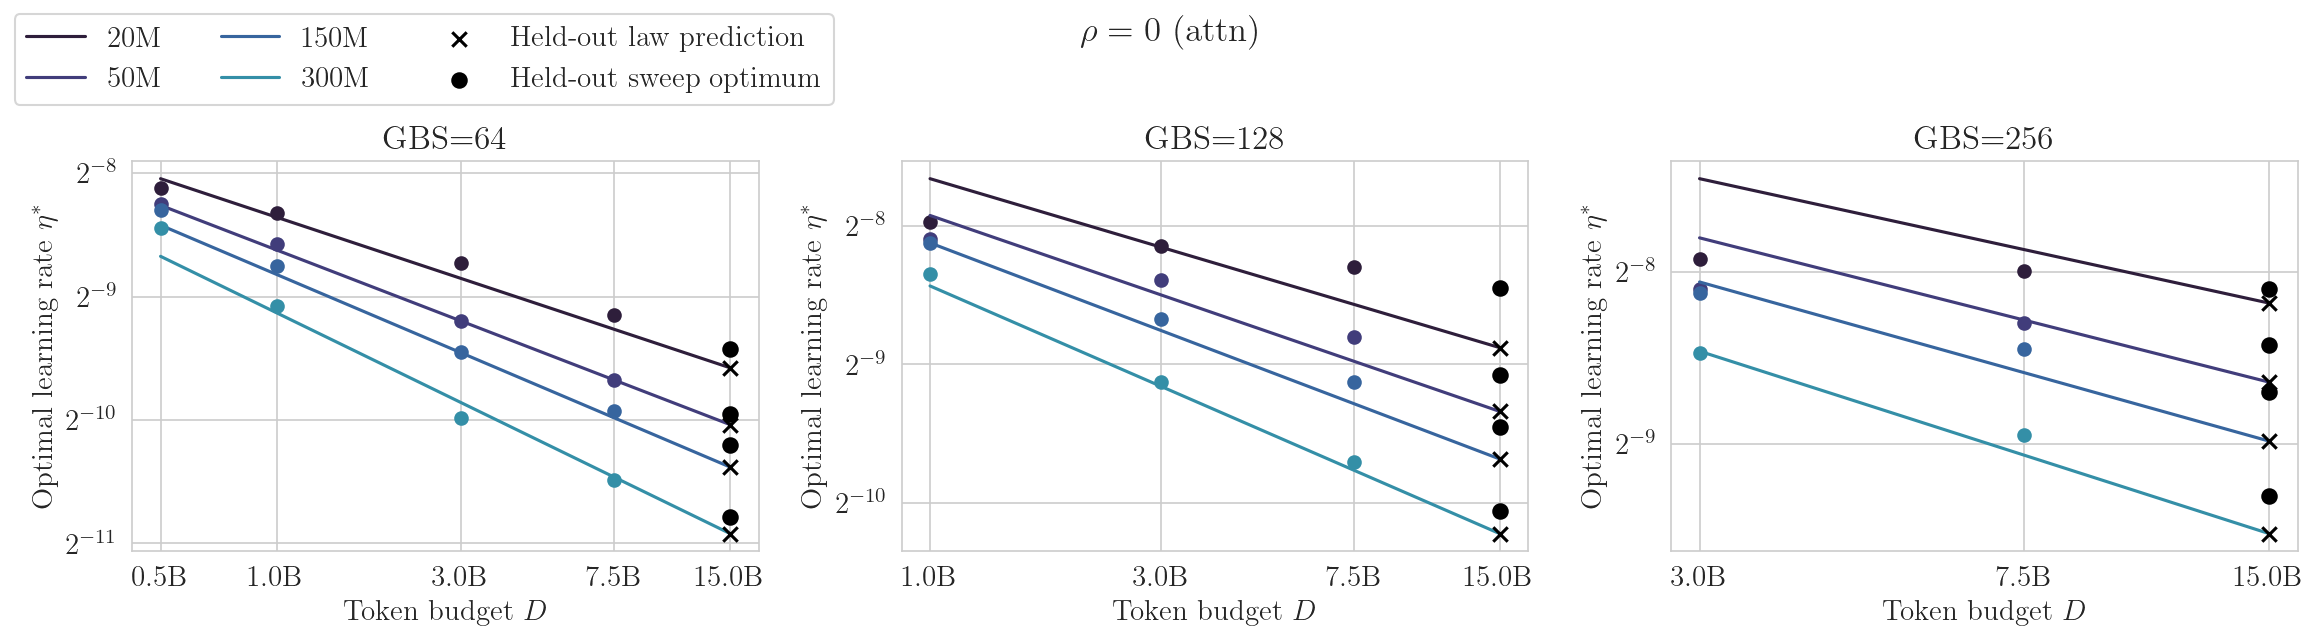

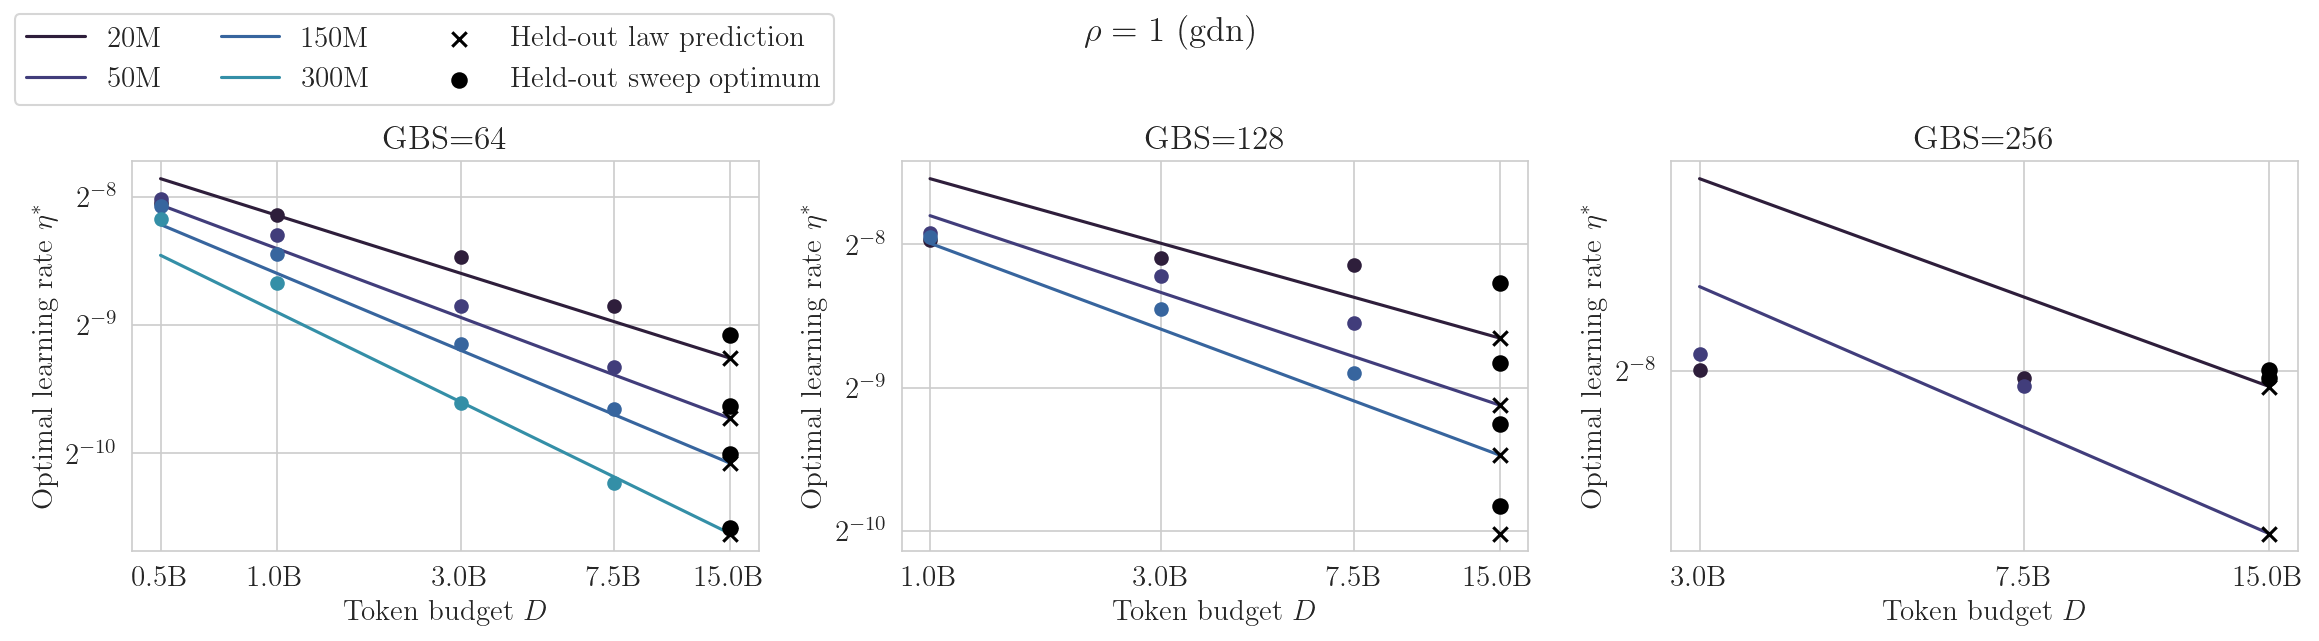

,test_cells,median_abs_log2_error,rmse_log2,median_fold_error,max_fold_error,fraction_within_2x,training_cells,matrix_rank,condition_number
architecture,,,,,,,,,
attn,12.0,0.196811,0.223685,1.146289,1.348323,1.0,56,5,2.125998
gdn,10.0,0.186374,0.253285,1.137904,1.435777,1.0,49,5,2.125548


In [229]:
validation_optima = {
    arch_id: collect_validation_lr_optima(
        arch_id,
        VALIDATION_GBSS,
        lr_filter=in_lr_grid if arch_id == "attn" else None,
    )
    for arch_id in VALIDATION_ARCHITECTURES
}

d_holdout_results = {}
d_holdout_summaries = []

for arch_id, architecture_label in VALIDATION_ARCHITECTURES.items():
    optima = validation_optima[arch_id]
    training_rows = optima[optima["data_scale"] != DATA_SCALES[-1]]
    test_rows = optima[optima["data_scale"] == DATA_SCALES[-1]]
    validation_fit = fit_validation_lr_law(training_rows)
    evaluated = evaluate_validation_lr_law(validation_fit, test_rows)
    d_holdout_results[arch_id] = evaluated

    summary_row = summarise_lr_law_validation(evaluated)
    summary_row["architecture"] = arch_id
    summary_row["training_cells"] = len(training_rows)
    summary_row["matrix_rank"] = validation_fit["rank"]
    summary_row["condition_number"] = validation_fit["condition_number"]
    d_holdout_summaries.append(summary_row)

    plot_lr_law_validation(
        training_rows,
        evaluated,
        validation_fit,
        held_out="data_scale",
        architecture_label=architecture_label,
    )

d_holdout_summary = pd.DataFrame(d_holdout_summaries).set_index("architecture")
display(d_holdout_summary)


## Validation 2: hold out the largest model size

The law is fitted using every available token budget and batch size but excluding
$N=300$M. Coloured dots are the optima used to fit the law, and their matching
curves show the fitted law across token budgets. Model sizes use the same colours as in
the unified learning-rate-law plots. The black dashed curve and crosses are predictions
for $N=300$M; black dots are optima estimated independently from its held-out sweeps. The
metrics use symmetric multiplicative error: a two-fold over-prediction and a two-fold
under-prediction both have a fold error of 2.


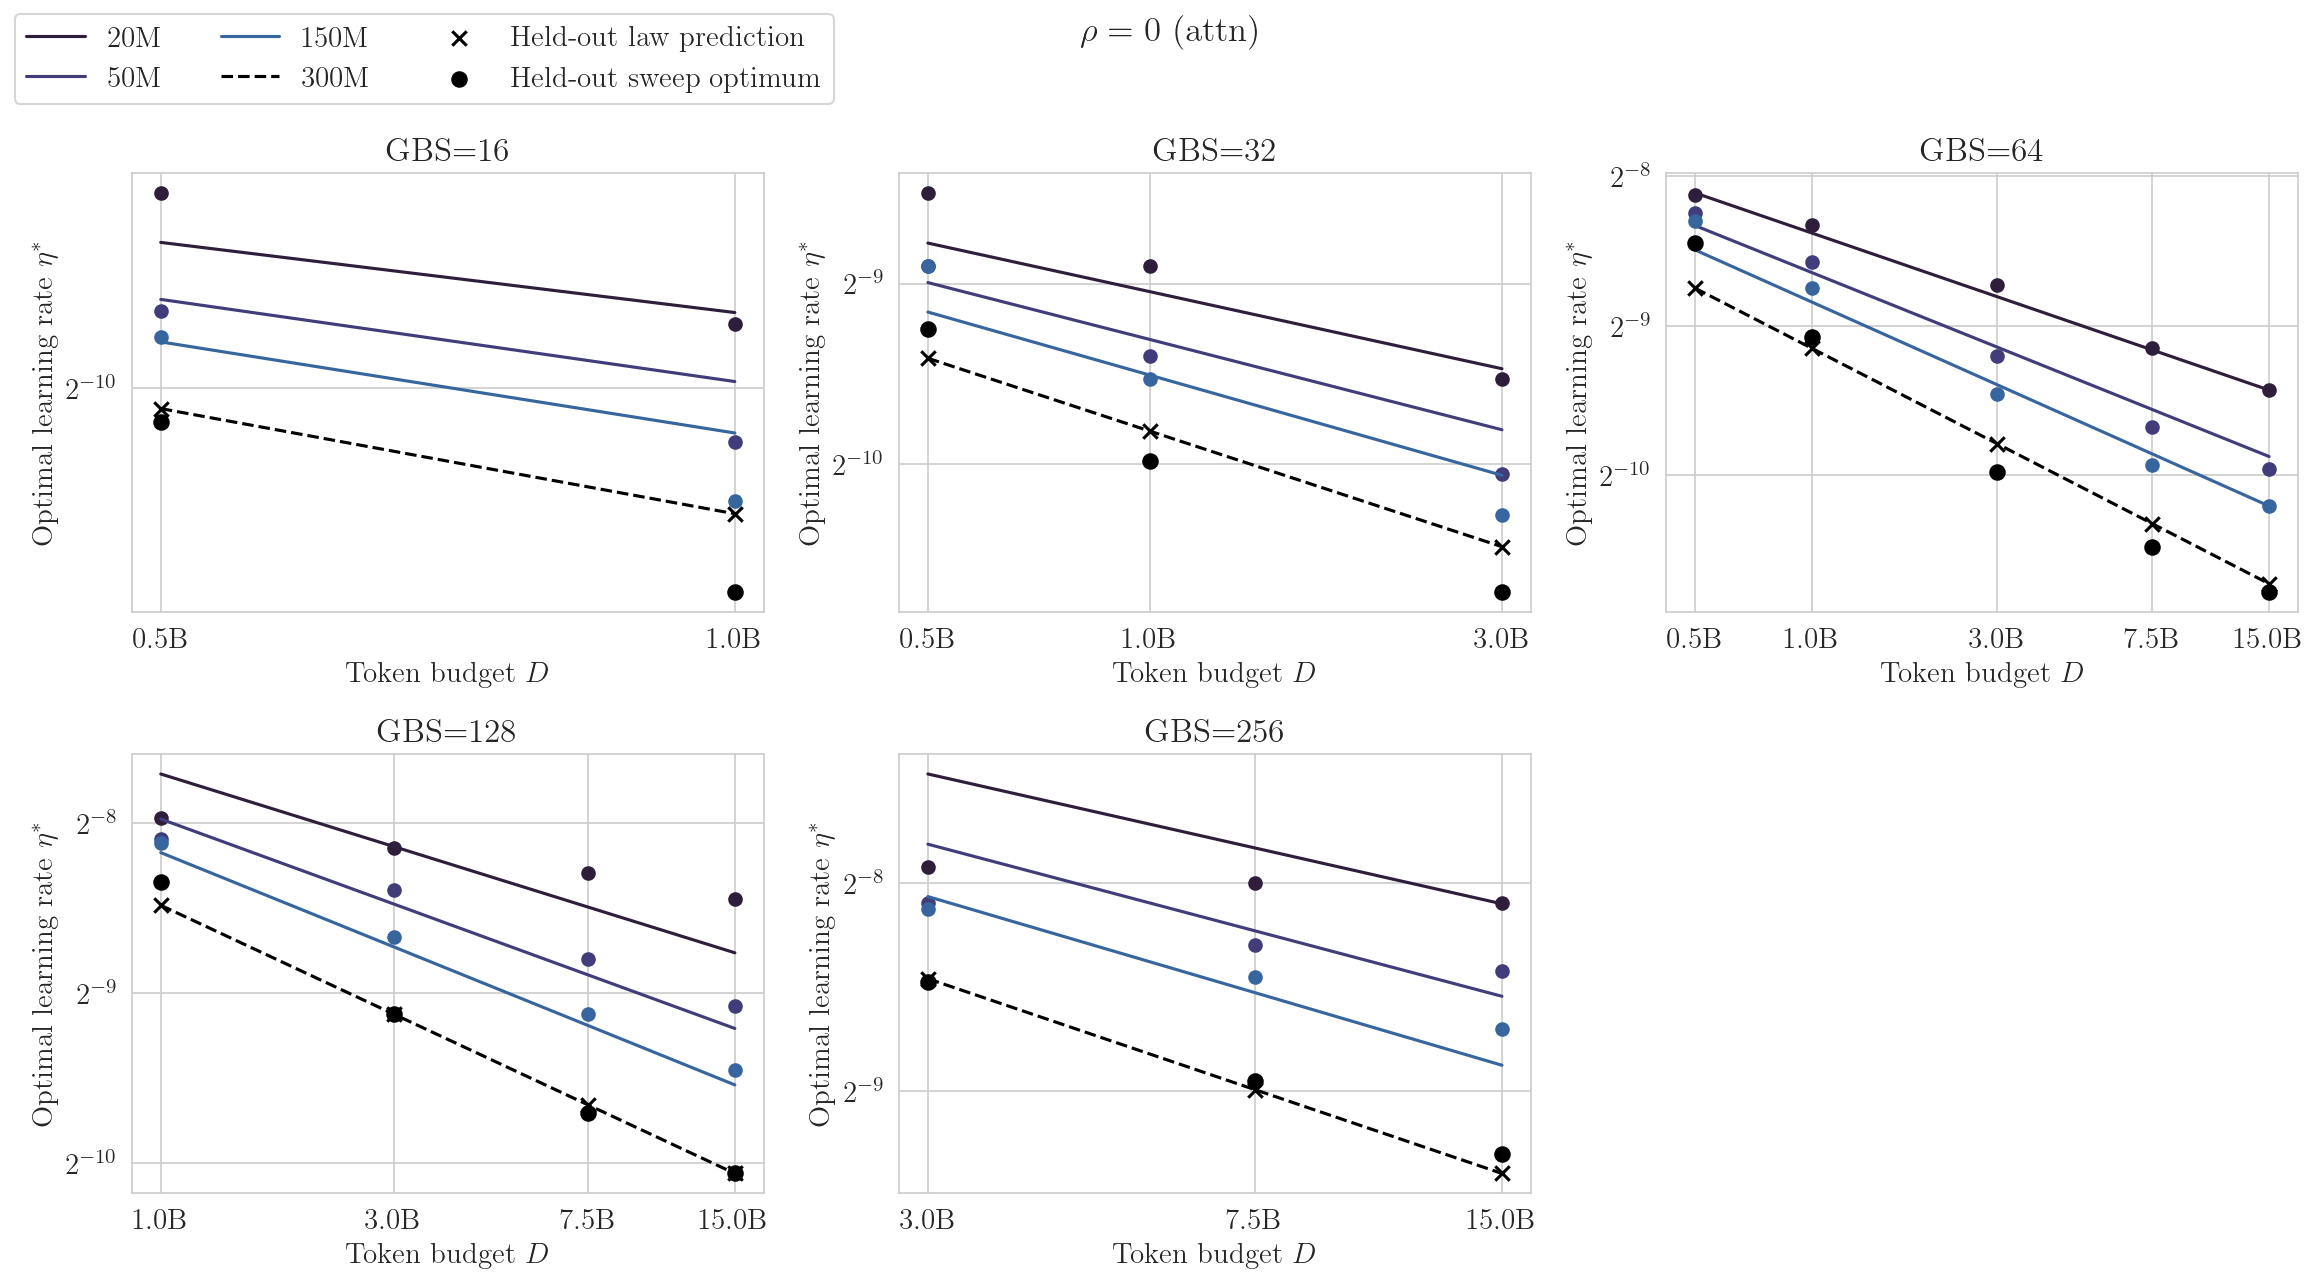

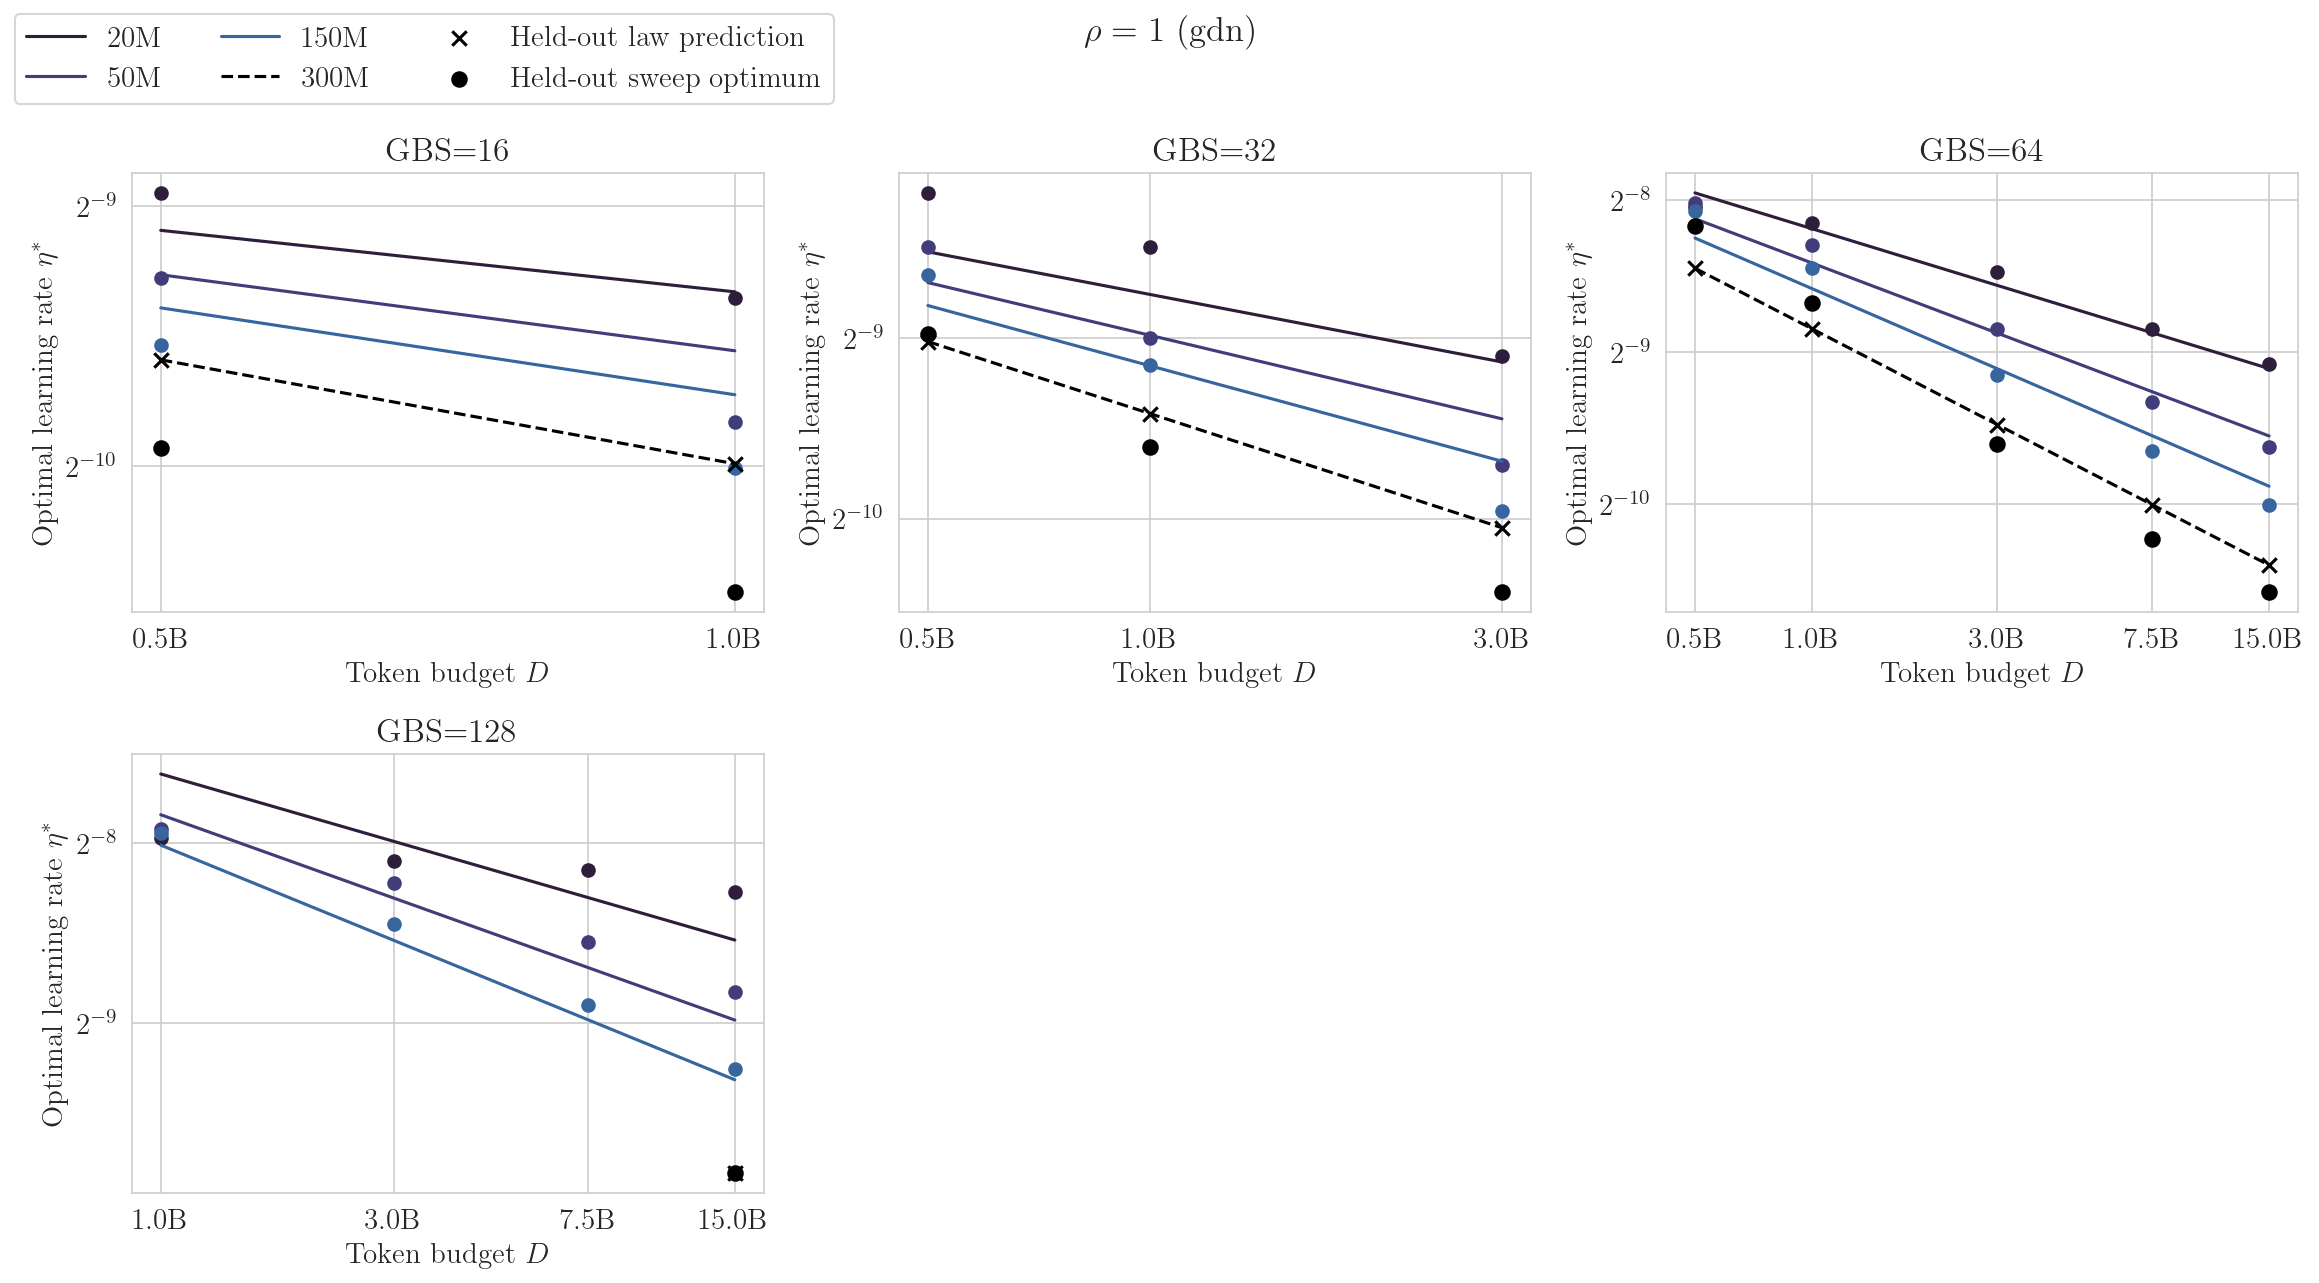

,test_cells,median_abs_log2_error,rmse_log2,median_fold_error,max_fold_error,fraction_within_2x,training_cells,matrix_rank,condition_number
architecture,,,,,,,,,
attn,17.0,0.092918,0.153817,1.066525,1.232582,1.0,51,5,2.299960
gdn,11.0,0.185580,0.257370,1.137274,1.407961,1.0,48,5,2.380627


In [230]:
n_holdout_results = {}
n_holdout_summaries = []

for arch_id, architecture_label in VALIDATION_ARCHITECTURES.items():
    optima = validation_optima[arch_id]
    training_rows = optima[optima["n"] != PARAM_SCALES[-1]]
    test_rows = optima[optima["n"] == PARAM_SCALES[-1]]
    validation_fit = fit_validation_lr_law(training_rows)
    evaluated = evaluate_validation_lr_law(validation_fit, test_rows)
    n_holdout_results[arch_id] = evaluated

    summary_row = summarise_lr_law_validation(evaluated)
    summary_row["architecture"] = arch_id
    summary_row["training_cells"] = len(training_rows)
    summary_row["matrix_rank"] = validation_fit["rank"]
    summary_row["condition_number"] = validation_fit["condition_number"]
    n_holdout_summaries.append(summary_row)

    plot_lr_law_validation(
        training_rows,
        evaluated,
        validation_fit,
        held_out="n",
        architecture_label=architecture_label,
    )

n_holdout_summary = pd.DataFrame(n_holdout_summaries).set_index("architecture")
display(n_holdout_summary)
